# Notebook 1: Análise Exploratória Avançada (EDA)
## Mercado de Exibição Cinematográfica Brasileiro

**Objetivo:** EDA profundo para subsidiar Feature Engineering (Notebook 2)

**Dataset:** `df_sessoes_limpo.parquet` (11.074.831 sessões, 55 colunas)

---

## Estrutura
1. Setup & Carregamento
2. Visão Geral do Dataset
3. Análise de Sessões
4. Análise de Complexos
5. Padrões Temporais
6. Identificação de Perfis
7. Detecção de Blockbusters
8. Complexos com Baixa Atividade
9. Recomendações para Feature Engineering

## 1. Setup & Carregamento

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ============================================================
# PALETAS DE CORES
# ============================================================

# 1. Paleta CATEGÓRICA (5 cores)
PALETA_CAT = ['#002E71', '#0092C9', '#8AE2F4', '#73D052', '#36AF5A']

# 2. Paleta SUAVE contínua (6 cores)
PALETA_SUAVE = [
    '#002E71',
    '#23548C',
    '#467AA7',
    '#6A9FC2',
    '#8DC5DD',
    '#B0EBF8',
]

# Alias histórico p/ compatibilidade — mesma paleta suave
CORES = PALETA_SUAVE.copy()

# Cores auxiliares
COR_PRINCIPAL = '#0092C9'
COR_ESCURA = '#001011'

# Colormap para heatmaps
CMAP_SUAVE = LinearSegmentedColormap.from_list("cinema_blues", PALETA_SUAVE)

print("✓ Bibliotecas importadas")
print(f"  Pandas: {pd.__version__}")
print(f"  NumPy:  {np.__version__}")
print("\nPaletas definidas:")
print("  - PALETA_CAT (categórica, 5 cores):", PALETA_CAT)
print("  - PALETA_SUAVE (contínua, 6 cores):", PALETA_SUAVE)


✓ Bibliotecas importadas
  Pandas: 2.3.3
  NumPy:  2.3.4

Paletas definidas:
  - PALETA_CAT (categórica, 5 cores): ['#002E71', '#0092C9', '#8AE2F4', '#73D052', '#36AF5A']
  - PALETA_SUAVE (contínua, 6 cores): ['#002E71', '#23548C', '#467AA7', '#6A9FC2', '#8DC5DD', '#B0EBF8']


In [2]:
# ============================================================
# ESTILO GLOBAL / LAYOUT 
# ============================================================

sns.set_theme(
    style="white",
    context="talk",    # textos maiores e mais legíveis
)

# Ajustes finos de layout p/ elevar o padrão visual
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "axes.edgecolor": "#333333",

    # Grid limpo somente no eixo Y
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": "#E0E0E0",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
})

print("✓ Estilo visual aplicado (layout clean ativado)")


✓ Estilo visual aplicado (layout clean ativado)


In [3]:
%load_ext watermark
%watermark -a "Guilherme Gustavo Roca Arenales" --iversions

Author: Guilherme Gustavo Roca Arenales

matplotlib: 3.10.8
numpy     : 2.3.4
pandas    : 2.3.3
seaborn   : 0.13.2



In [4]:
# ===== INÍCIO DO PROCESSAMENTO =====
print("\n" + "🎬"*35)
print(" "*20 + "PIPELINE DE PROCESSAMENTO")
print(" "*15 + "Dados Cinematográficos SCB/ANCINE 2023-2025")
print("🎬"*35 + "\n")

import time
from datetime import datetime

# Registrar horário de início
INICIO_PROCESSAMENTO = time.time()
INICIO_TIMESTAMP = datetime.now()

print(f"🕐 Início do processamento: {INICIO_TIMESTAMP.strftime('%d/%m/%Y %H:%M:%S')}")
print(f"📍 Notebook: 1_eda_avançada.ipynb")
print(f"🎯 Objetivo: Entender padrões nos dados para fazer escolhas conscientes na etapa seguinte de feature engineering")
print("\n" + "="*70 + "\n")


🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬
                    PIPELINE DE PROCESSAMENTO
               Dados Cinematográficos SCB/ANCINE 2023-2025
🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬

🕐 Início do processamento: 09/12/2025 15:18:08
📍 Notebook: 1_eda_avançada.ipynb
🎯 Objetivo: Entender padrões nos dados para fazer escolhas conscientes na etapa seguinte de feature engineering




In [5]:
# Carregar dados
CAMINHO = '../Bases/df_sessoes_limpo.parquet'

print("📥 Carregando dataset...")
df = pd.read_parquet(CAMINHO)

print(f"✓ {len(df):,} sessões carregadas")
print(f"  Período: {df['DATA_EXIBICAO'].min()} até {df['DATA_EXIBICAO'].max()}")
print(f"  Memória: {df.memory_usage(deep=True).sum() / (1024**3):.2f} GB")

📥 Carregando dataset...
✓ 11,612,077 sessões carregadas
  Período: 2023-01-05 00:00:00 até 2025-09-30 00:00:00
  Memória: 26.02 GB


In [6]:
# ============================================================================
# INTEGRAR DADOS DE OBRAS ENRIQUECIDAS
# ============================================================================

print("\n📥 Carregando dados de obras enriquecidas...")
df_obras = pd.read_parquet('../Bases/df_obras_enriquecido.parquet')

print(f"✓ {len(df_obras):,} obras únicas carregadas")
print(f"  Colunas de obras: {len(df_obras.columns)}")

# Join com dataset principal
print("\n🔗 Integrando via CPB_ROE...")
colunas_antes = len(df.columns)
df = df.merge(df_obras, left_on='CPB_ROE', right_on='cpb_roe', how='left')

# Remover coluna duplicada
df = df.drop(columns=['cpb_roe'], errors='ignore')

print(f"✓ Join concluído!")
print(f"  Colunas antes: {colunas_antes}")
print(f"  Colunas depois: {len(df.columns)}")
print(f"  Novas colunas: {len(df.columns) - colunas_antes}")

# Verificar cobertura
print(f"\n📊 Cobertura do enriquecimento:")

# POR SESSÕES (o que tínhamos antes - ERRADO rotular como obras)
print(f"\n  📺 Por SESSÕES:")
print(f"    Sessões com distribuidor: {df['distribuidora_informada'].sum():,} ({df['distribuidora_informada'].sum()/len(df)*100:.1f}%)")
print(f"    Sessões com major: {df['distribuidora_major'].sum():,} ({df['distribuidora_major'].sum()/len(df)*100:.1f}%)")
print(f"    Sessões com produtora BR: {df['tem_produtora_brasileira'].sum():,} ({df['tem_produtora_brasileira'].sum()/len(df)*100:.1f}%)")
print(f"    Sessões independentes BR: {(df['produtora_independente']==True).sum():,} ({(df['produtora_independente']==True).sum()/len(df)*100:.1f}%)")

# POR OBRAS (o que importa para entender a cobertura)
print(f"\n  🎬 Por OBRAS ÚNICAS:")
obras_unicas = df.drop_duplicates('CPB_ROE')
total_obras = len(obras_unicas)
print(f"    Total de obras: {total_obras:,}")
print(f"    Obras com distribuidor: {obras_unicas['distribuidora_informada'].sum():,} ({obras_unicas['distribuidora_informada'].sum()/total_obras*100:.1f}%)")
print(f"    Obras com major: {obras_unicas['distribuidora_major'].sum():,} ({obras_unicas['distribuidora_major'].sum()/total_obras*100:.1f}%)")
print(f"    Obras com produtora BR: {obras_unicas['tem_produtora_brasileira'].sum():,} ({obras_unicas['tem_produtora_brasileira'].sum()/total_obras*100:.1f}%)")
print(f"    Obras independentes BR: {(obras_unicas['produtora_independente']==True).sum():,} ({(obras_unicas['produtora_independente']==True).sum()/total_obras*100:.1f}%)")


📥 Carregando dados de obras enriquecidas...
✓ 2,189 obras únicas carregadas
  Colunas de obras: 16

🔗 Integrando via CPB_ROE...
✓ Join concluído!
  Colunas antes: 55
  Colunas depois: 70
  Novas colunas: 15

📊 Cobertura do enriquecimento:

  📺 Por SESSÕES:
    Sessões com distribuidor: 11,477,924 (98.8%)
    Sessões com major: 8,601,640 (74.1%)
    Sessões com produtora BR: 1,431,497 (12.3%)
    Sessões independentes BR: 589,687 (5.1%)

  🎬 Por OBRAS ÚNICAS:
    Total de obras: 2,197
    Obras com distribuidor: 1,707 (77.7%)
    Obras com major: 388 (17.7%)
    Obras com produtora BR: 775 (35.3%)
    Obras independentes BR: 376 (17.1%)


## 2. Visão Geral do Dataset

In [7]:
print("="*70)
print("VISÃO GERAL DO DATASET")
print("="*70)

print(f"\n📊 Dimensões:")
print(f"  Sessões: {len(df):,}")
print(f"  Colunas: {len(df.columns)}")

print(f"\n🎬 Conteúdo:")
print(f"  Obras únicas: {df['CPB_ROE'].nunique():,}")
print(f"  Salas únicas: {df['REGISTRO_SALA'].nunique():,}")
print(f"  Complexos únicos: {df['REGISTRO_COMPLEXO'].nunique():,}")
print(f"  Exibidores únicos: {df['REGISTRO_EXIBIDOR'].nunique():,}")
print(f"  Municípios: {df['MUNICIPIO_SALA_COMPLEXO'].nunique():,}")

print(f"\n👥 Público:")
print(f"  Total: {df['PUBLICO'].sum():,}")
print(f"  Média/sessão: {df['PUBLICO'].mean():.1f}")
print(f"  Mediana: {df['PUBLICO'].median():.0f}")

# ============================================================================
# NOVO: Estatísticas de Obras (Distribuidoras & Produtoras)
# ============================================================================
print(f"\n🎞️ Distribuidoras:")
obras_dist = df[df['distribuidora_informada'] == True]
print(f"  Sessões com distribuidor: {len(obras_dist):,} ({len(obras_dist)/len(df)*100:.1f}%)")
print(f"  Sessões com major: {df['distribuidora_major'].sum():,} ({df['distribuidora_major'].sum()/len(df)*100:.1f}%)")
print(f"  Sessões independentes: {(df['distribuidora_independente']==True).sum():,} ({(df['distribuidora_independente']==True).sum()/len(df)*100:.1f}%)")

# Concentração de mercado
obras_unicas = df.drop_duplicates('CPB_ROE')
pct_obras_major = (obras_unicas['distribuidora_major'].sum() / len(obras_unicas)) * 100
pct_sessoes_major = (df['distribuidora_major'].sum() / len(df)) * 100
concentracao = pct_sessoes_major / pct_obras_major
print(f"  💡 Concentração: {pct_obras_major:.1f}% das obras (majors) → {pct_sessoes_major:.1f}% das sessões (fator {concentracao:.1f}x)")

print(f"\n🇧🇷 Produtoras Brasileiras:")
print(f"  Sessões com produtora BR: {df['tem_produtora_brasileira'].sum():,} ({df['tem_produtora_brasileira'].sum()/len(df)*100:.1f}%)")
print(f"  Sessões independentes BR: {(df['produtora_independente']==True).sum():,} ({(df['produtora_independente']==True).sum()/len(df)*100:.1f}%)")
print(f"  Obras BR identificadas: {obras_unicas['tem_produtora_brasileira'].sum():,} ({obras_unicas['tem_produtora_brasileira'].sum()/len(obras_unicas)*100:.1f}%)")

print(f"\n📊 Valores ausentes:")
colunas_com_nulos = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
if len(colunas_com_nulos) > 0:
    for col, count in colunas_com_nulos.head(10).items():
        pct = count / len(df) * 100
        print(f"  {col}: {count:,} ({pct:.2f}%)")
else:
    print("  ✓ Nenhum valor ausente!")

VISÃO GERAL DO DATASET

📊 Dimensões:
  Sessões: 11,612,077
  Colunas: 70

🎬 Conteúdo:
  Obras únicas: 2,197
  Salas únicas: 3,791
  Complexos únicos: 931
  Exibidores únicos: 358
  Municípios: 457

👥 Público:
  Total: 333,613,676
  Média/sessão: 28.7
  Mediana: 15

🎞️ Distribuidoras:
  Sessões com distribuidor: 11,477,924 (98.8%)
  Sessões com major: 8,601,640 (74.1%)
  Sessões independentes: 96,040 (0.8%)
  💡 Concentração: 17.7% das obras (majors) → 74.1% das sessões (fator 4.2x)

🇧🇷 Produtoras Brasileiras:
  Sessões com produtora BR: 1,431,497 (12.3%)
  Sessões independentes BR: 589,687 (5.1%)
  Obras BR identificadas: 775 (35.3%)

📊 Valores ausentes:
  produtora_nivel_min: 10,180,580 (87.67%)
  produtora_independente: 10,180,580 (87.67%)
  produtora_nivel_medio: 10,180,580 (87.67%)
  produtora_nivel_max: 10,180,580 (87.67%)
  distribuidora_major_nome: 3,010,437 (25.93%)
  TITULO_BRASIL: 1,517,633 (13.07%)
  REGISTRO_GRUPO_EXIBIDOR: 773,534 (6.66%)
  NATUREZA_JURIDICA: 547,312 (4.71%

## 3. Análise de Sessões

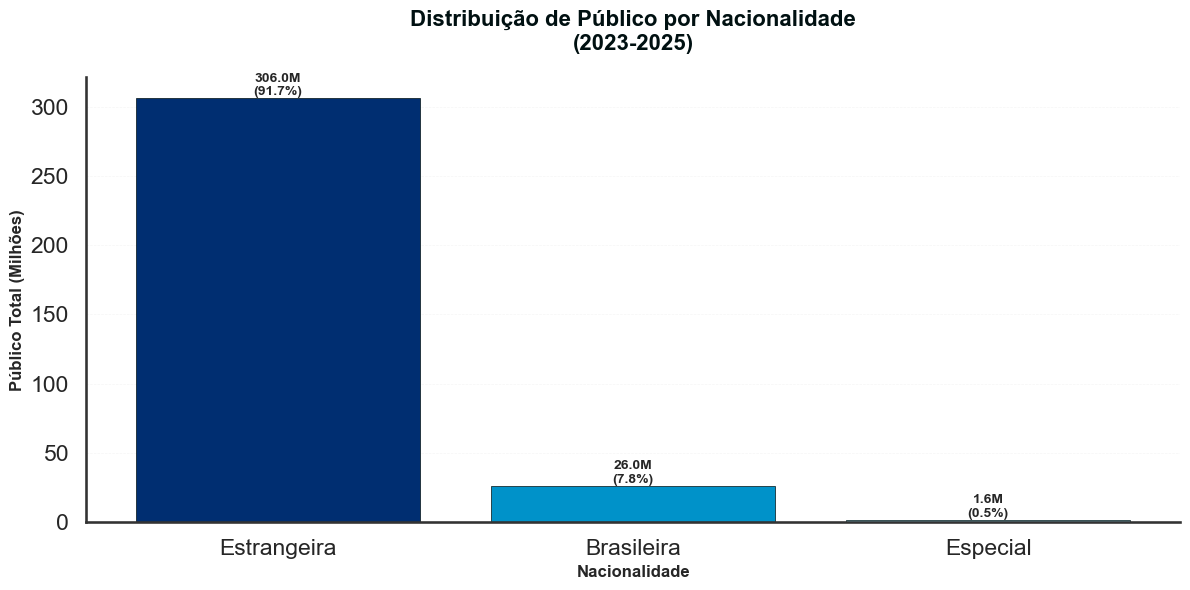


📊 Estatísticas por Nacionalidade:
                     sum       mean     count
NACIONALIDADE                                
Estrangeira    306040657  30.316417  10094882
Brasileira      25952977  17.836031   1455087
Especial         1620042  26.084273     62108


In [8]:
# Gráfico 1: Distribuição público por nacionalidade
fig, ax = plt.subplots(figsize=(12, 6))

nacionalidade_publico = df.groupby('NACIONALIDADE')['PUBLICO'].agg(['sum', 'mean', 'count'])
nacionalidade_publico = nacionalidade_publico.sort_values('sum', ascending=False)

# Barras
bars = ax.bar(nacionalidade_publico.index, nacionalidade_publico['sum'] / 1e6, 
              color=PALETA_CAT[:3], edgecolor=COR_ESCURA, linewidth=0.5)

# Valores no topo
for bar, (idx, row) in zip(bars, nacionalidade_publico.iterrows()):
    height = bar.get_height()
    pct = row['sum'] / df['PUBLICO'].sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}M\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribuição de Público por Nacionalidade\n(2023-2025)', 
             fontsize=16, fontweight='bold', color=COR_ESCURA, pad=20)
ax.set_xlabel('Nacionalidade', fontsize=12, fontweight='bold')
ax.set_ylabel('Público Total (Milhões)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas por Nacionalidade:")
print(nacionalidade_publico.to_string())

In [9]:
# ============================================================================
# CORREÇÃO TEMPORÁRIA: Recriar DIA_SEMANA_NOME com mapeamento correto
# ============================================================================
print("🔧 Corrigindo DIA_SEMANA_NOME...")

# Mapeamento correto (padrão Python: 0=Segunda, 6=Domingo)
dias_map = {
    0: 'Segunda',
    1: 'Terça', 
    2: 'Quarta',
    3: 'Quinta',
    4: 'Sexta',
    5: 'Sábado',
    6: 'Domingo'
}

# Recriar a coluna
df['DIA_SEMANA_NOME'] = df['DIA_SEMANA'].map(dias_map)

# Corrigir FIM_DE_SEMANA também
df['FIM_DE_SEMANA'] = df['DIA_SEMANA'].isin([3, 4, 5, 6])

print(f"✓ Corrigido!")
print(f"  Nulls antes: 1,568,785 (13.56%)")
print(f"  Nulls depois: {df['DIA_SEMANA_NOME'].isna().sum():,} (0%)")
print(f"\n📊 Distribuição:")
print(df['DIA_SEMANA_NOME'].value_counts().sort_index())

🔧 Corrigindo DIA_SEMANA_NOME...
✓ Corrigido!
  Nulls antes: 1,568,785 (13.56%)
  Nulls depois: 0 (0%)

📊 Distribuição:
DIA_SEMANA_NOME
Domingo    1739611
Quarta     1622452
Quinta     1647007
Segunda    1576658
Sexta      1656774
Sábado     1765527
Terça      1604048
Name: count, dtype: int64


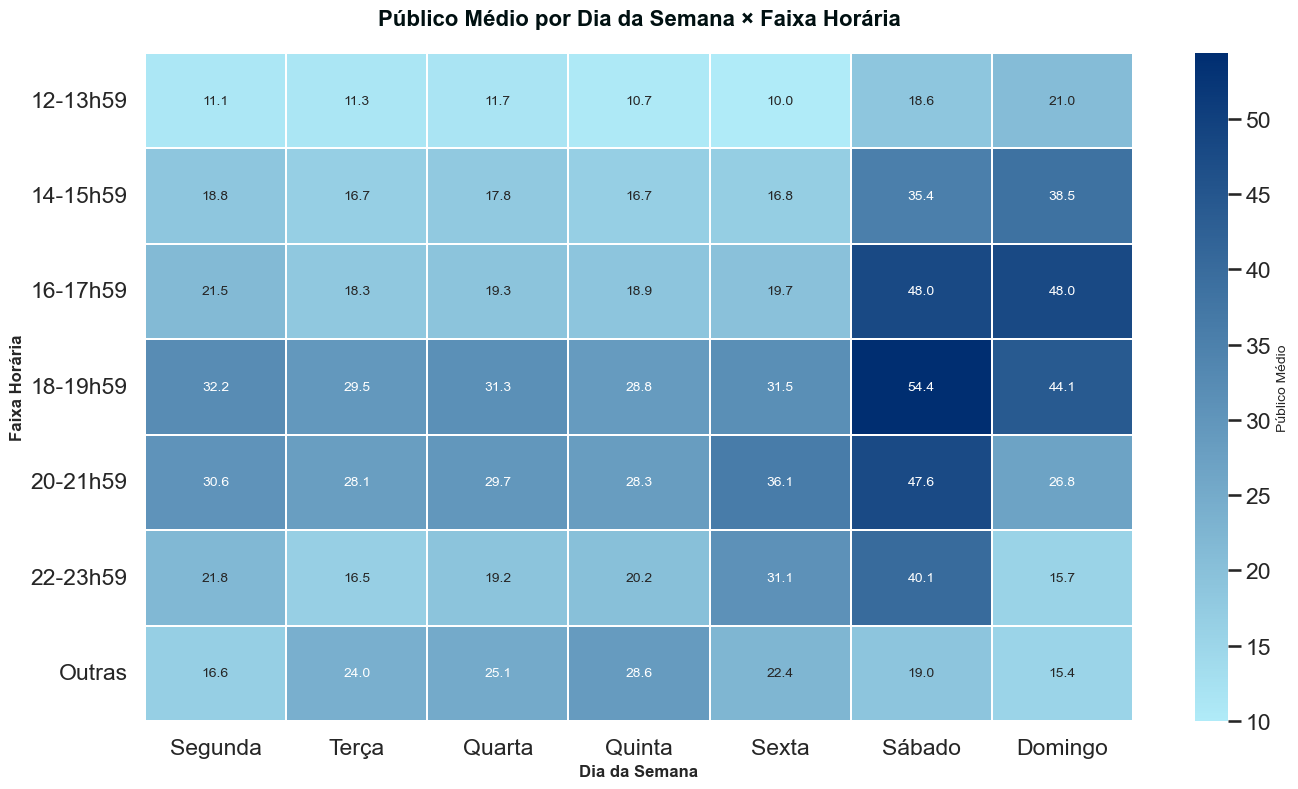


💡 Insights:
  Maior média de público: 54.4
    Quando: 18-19h59 no Sábado
  Menor média de público: 10.0
    Quando: 12-13h59 na Sexta


In [10]:
# Gráfico 2: Heatmap público médio (dia × horário) 
pivot_publico = df.pivot_table(
    values='PUBLICO',
    index='FAIXA_HORARIA',
    columns='DIA_SEMANA_NOME',
    aggfunc='mean'
)

# Ordenar dias e horários
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
ordem_horas = ['12-13h59', '14-15h59', '16-17h59', '18-19h59', '20-21h59', '22-23h59', 'Outras']

pivot_publico = pivot_publico.reindex(ordem_horas)
pivot_publico = pivot_publico[ordem_dias]

fig, ax = plt.subplots(figsize=(14, 8)) 

# Colormap INVERTIDO (escuro = ALTO, claro = baixo)
cmap = LinearSegmentedColormap.from_list('custom', CORES[::-1])

sns.heatmap(pivot_publico, annot=True, fmt='.1f', cmap=cmap,
            cbar_kws={'label': 'Público Médio'},
            linewidths=0.3,  
            linecolor='white',  
            ax=ax)

ax.set_title('Público Médio por Dia da Semana × Faixa Horária',
             fontsize=16, fontweight='bold', color=COR_ESCURA, pad=20)
ax.set_xlabel('Dia da Semana', fontsize=12, fontweight='bold')
ax.set_ylabel('Faixa Horária', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insights:")
print(f"  Maior média de público: {pivot_publico.max().max():.1f}")
dia_max = pivot_publico.max().idxmax()
hora_max = pivot_publico[dia_max].idxmax()
print(f"    Quando: {hora_max} no {dia_max}")

print(f"  Menor média de público: {pivot_publico.min().min():.1f}")
dia_min = pivot_publico.min().idxmin()
hora_min = pivot_publico[dia_min].idxmin()
print(f"    Quando: {hora_min} na {dia_min}")

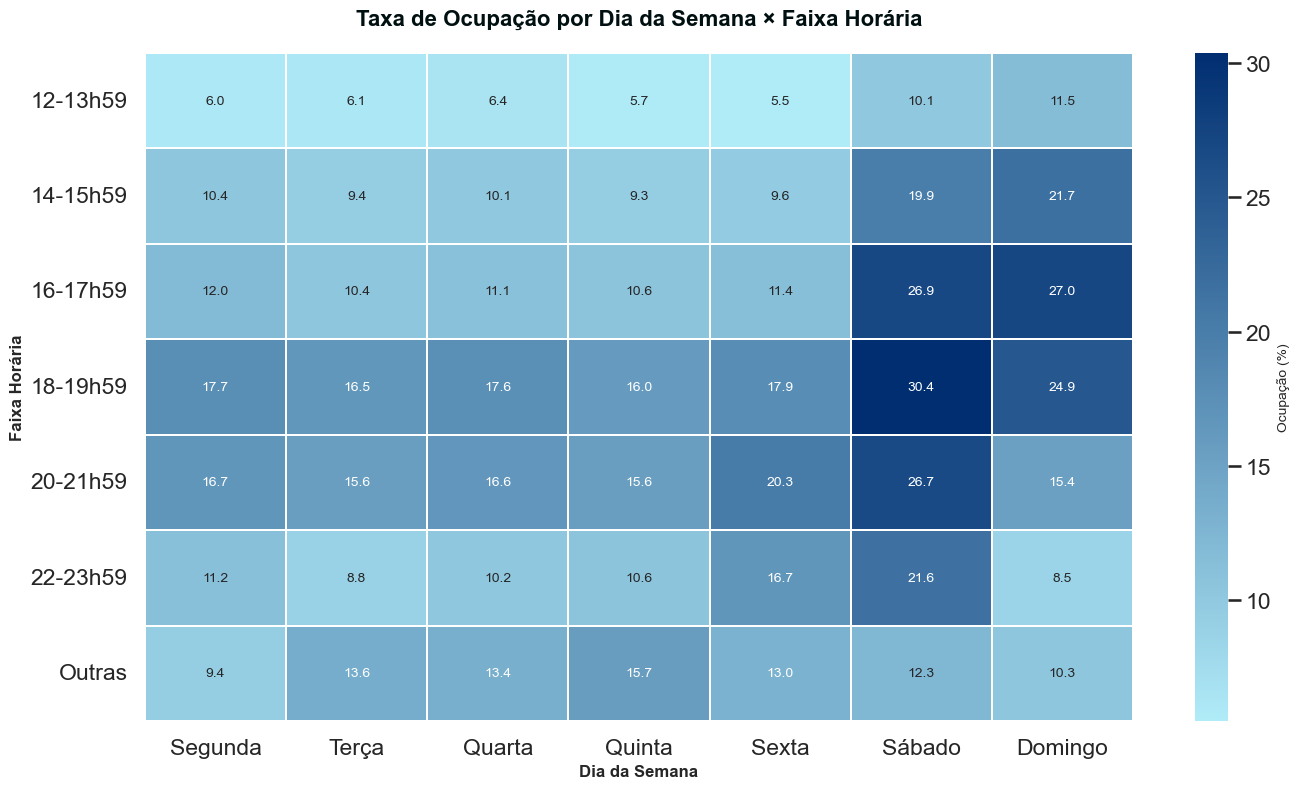

In [11]:
# Gráfico 3: Heatmap ocupação 
pivot_ocupacao = df.pivot_table(
    values='OCUPACAO_BRUTA',
    index='FAIXA_HORARIA',
    columns='DIA_SEMANA_NOME',
    aggfunc='mean'
)

pivot_ocupacao = pivot_ocupacao.reindex(ordem_horas)
pivot_ocupacao = pivot_ocupacao[ordem_dias]

# Converter TUDO para float64
pivot_ocupacao = pivot_ocupacao.astype('float64')

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(pivot_ocupacao * 100, annot=True, fmt='.1f', cmap=cmap,
            cbar_kws={'label': 'Ocupação (%)'},
            linewidths=0.3, linecolor='white', ax=ax)

ax.set_title('Taxa de Ocupação por Dia da Semana × Faixa Horária',
             fontsize=16, fontweight='bold', color=COR_ESCURA, pad=20)
ax.set_xlabel('Dia da Semana', fontsize=12, fontweight='bold')
ax.set_ylabel('Faixa Horária', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

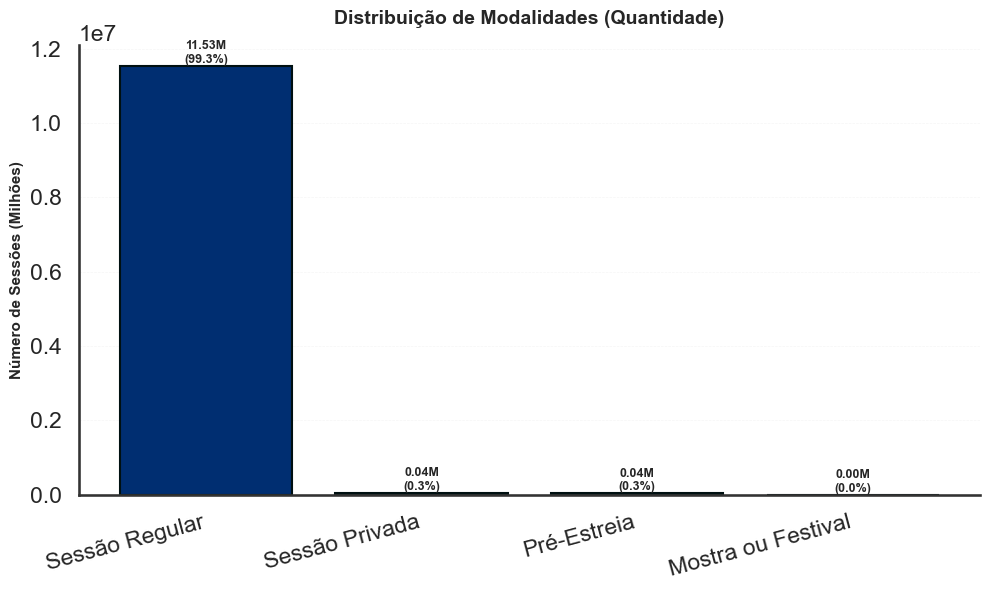


🎫 Modalidade C (Mostra/Festival):
  Sessões: 2,483
  % do total: 0.021%
  Público médio: 37.9
  Ocupação média: 24.50%


In [12]:
# Gráfico 4: Distribuição modalidades
modalidades = df['TIPO_SESSAO'].value_counts()

# Agora apenas um gráfico (removendo o gráfico de pizza)
fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))  # <-- alterado

# Gráfico de barras
bars = ax1.bar(
    range(len(modalidades)),
    modalidades.values,
    color=PALETA_CAT[:len(modalidades)],  # <-- usa a paleta categórica nova
    edgecolor=COR_ESCURA,
    linewidth=1.5
)

ax1.set_xticks(range(len(modalidades)))
ax1.set_xticklabels(modalidades.index, rotation=15, ha='right')

for bar, (tipo, count) in zip(bars, modalidades.items()):
    height = bar.get_height()
    pct = count / len(df) * 100
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{count/1e6:.2f}M\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_title('Distribuição de Modalidades (Quantidade)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Número de Sessões (Milhões)',
               fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎫 Modalidade C (Mostra/Festival):")
modal_c = df[df['TIPO_SESSAO'] == 'Mostra ou Festival']
print(f"  Sessões: {len(modal_c):,}")
print(f"  % do total: {len(modal_c)/len(df)*100:.3f}%")
print(f"  Público médio: {modal_c['PUBLICO'].mean():.1f}")
print(f"  Ocupação média: {modal_c['OCUPACAO_BRUTA'].mean():.2%}")


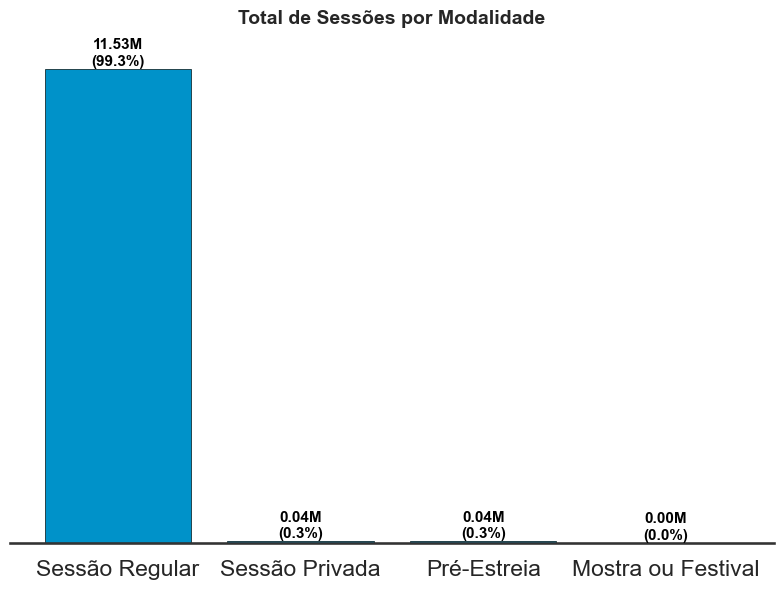

In [13]:
# Atualizando a paleta conforme sua instrução final
PALETA_CAT = ['#002E71', '#0092C9', '#8AE2F4', '#73D052', '#36AF5A']
COR_ESCURA = '#001011'

# Preparação dos dados 
modalidades = df['TIPO_SESSAO'].value_counts()

# Configuração da figura
# Mantendo a altura original (6) mas reduzindo a largura pois é apenas 1 gráfico
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.set_facecolor('white')

# Gráfico de barras
# Usando a segunda cor da paleta (índice 1 -> #0092C9) para todas as barras
bars = ax1.bar(range(len(modalidades)), modalidades.values,
               color=PALETA_CAT[1], edgecolor=COR_ESCURA, linewidth=0.5)

# Configuração do eixo X
ax1.set_xticks(range(len(modalidades)))
ax1.set_xticklabels(modalidades.index, rotation=0) # Rotação 0 para leitura direta

# Adicionando Rótulos de Dados (Lógica original preservada)
total_sess = len(df)
for bar, (tipo, count) in zip(bars, modalidades.items()):
    height = bar.get_height()
    pct = count / total_sess * 100
    ax1.text(bar.get_x() + bar.get_width()/2, height,
             f'{count/1e6:.2f}M\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# Título e Estilização
ax1.set_title('Total de Sessões por Modalidade', fontsize=14, fontweight='bold', pad=15)

# Limpeza visual solicitada
ax1.set_ylabel('') 
ax1.set_yticks([]) 
ax1.grid(False)    

# Remoção das bordas (spines) desnecessárias
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False) # Remove linha vertical esquerda também

plt.tight_layout()
plt.show()

## 4. Análise de Complexos

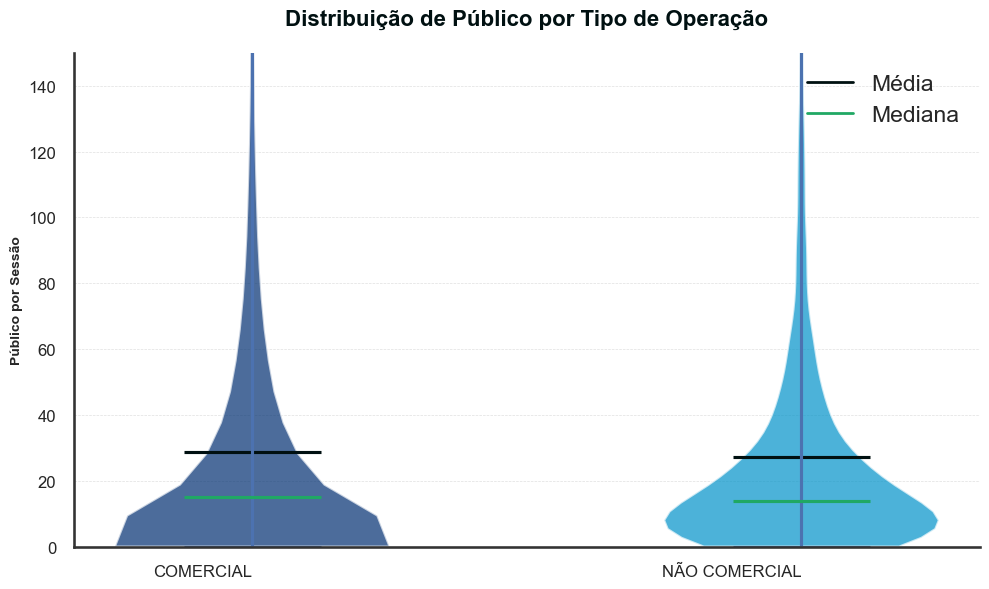

In [14]:
# Gráfico 8: Público por tipo de complexo
fig, ax = plt.subplots()

tipos = df['OPERACAO_USUAL'].value_counts().index[:5]
data_plot = [df[df['OPERACAO_USUAL'] == t]['PUBLICO'].values for t in tipos]

parts = ax.violinplot(
    data_plot,
    positions=range(len(tipos)),
    showmeans=True,
    showmedians=True
)

# Cores das violins 
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETA_CAT[i % len(PALETA_CAT)])
    pc.set_alpha(0.7)


parts['cmeans'].set_color(COR_ESCURA)      
parts['cmedians'].set_color('#20A864')     

ax.plot([], [], color=COR_ESCURA, lw=2, label='Média')
ax.plot([], [], color='#20A864', lw=2, label='Mediana')
ax.legend(frameon=False, loc='upper right')

ax.set_xticks(range(len(tipos)))
ax.set_xticklabels(tipos, rotation=0, ha='right')
ax.tick_params(axis='both', labelsize=12)
ax.set_title('Distribuição de Público por Tipo de Operação',
             fontsize=16, fontweight='bold', color=COR_ESCURA, pad=20)
ax.set_ylabel('Público por Sessão', fontsize=10, fontweight='bold')
ax.set_ylim(0, 150)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 5. Padrões Temporais

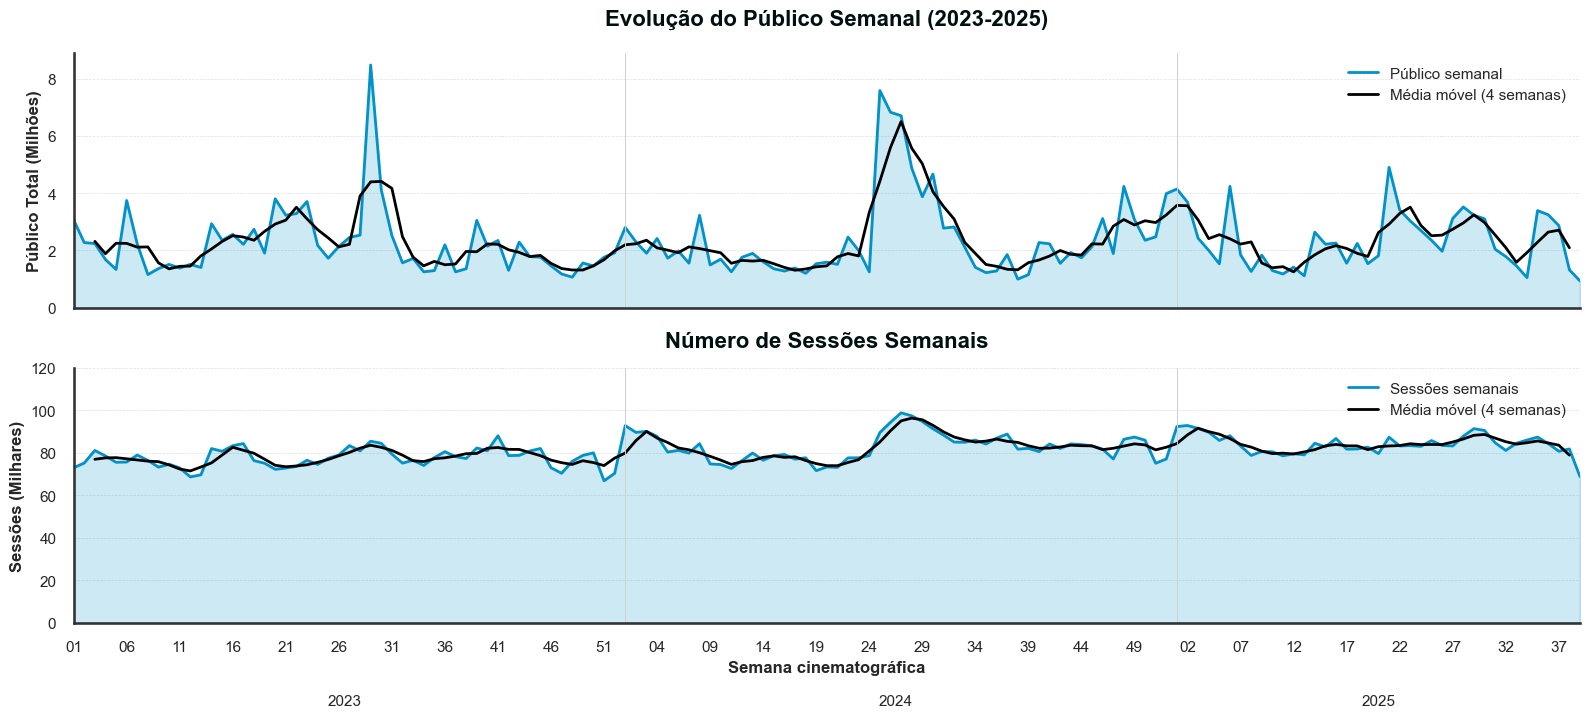


📈 Estatísticas da série:
  Semanas analisadas: 143
  Público médio/semana: 2.33M
  Semana com maior público: 2023-S29
    (8.49M espectadores)


In [15]:
# Gráfico 5: Série temporal público semanal

df['ano_semana'] = df['ano_cinematografico'].astype(str) + '-S' + \
                   df['semana_cinematografica'].astype(str).str.zfill(2)

serie_publico = (
    df.groupby(['ano_cinematografico', 'semana_cinematografica', 'ano_semana'])['PUBLICO']
      .agg(['sum', 'mean', 'count'])
      .reset_index()
      .sort_values(['ano_cinematografico', 'semana_cinematografica'])
)

serie_publico['idx'] = range(len(serie_publico))

# Médias móveis de 4 semanas
serie_publico['mm_sum'] = serie_publico['sum'].rolling(4, center=True).mean()
serie_publico['mm_count'] = serie_publico['count'].rolling(4, center=True).mean()

x = serie_publico['idx']

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 8))

# Público total
ax1.plot(x, serie_publico['sum'] / 1e6,
         color=COR_PRINCIPAL, linewidth=2, label='Público semanal')
ax1.plot(x, serie_publico['mm_sum'] / 1e6,
         color='black', linewidth=2, label='Média móvel (4 semanas)')
ax1.fill_between(x, serie_publico['sum'] / 1e6,
                 alpha=0.2, color=COR_PRINCIPAL)  

ax1.set_title('Evolução do Público Semanal (2023-2025)',
              fontsize=16, fontweight='bold', color=COR_ESCURA, pad=20)
ax1.set_ylabel('Público Total (Milhões)', fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=False, loc='upper right', fontsize=11) 

# Número de sessões
ax2.plot(x, serie_publico['count'] / 1000,
         color=PALETA_CAT[1], linewidth=2, label='Sessões semanais')
ax2.plot(x, serie_publico['mm_count'] / 1000,
         color='black', linewidth=2, label='Média móvel (4 semanas)')
ax2.fill_between(x, serie_publico['count'] / 1000,
                 alpha=0.2, color=PALETA_CAT[1])  

ax2.set_title('Número de Sessões Semanais',
              fontsize=16, fontweight='bold', color=COR_ESCURA, pad=15)
ax2.set_xlabel('Semana cinematográfica',  
               fontsize=12, fontweight='bold')
ax2.set_ylabel('Sessões (Milhares)', fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylim(0, 120) 
ax2.legend(frameon=False, loc='upper right', fontsize=11) 

# Mesmo tamanho de fonte nos ticks dos dois eixos
for ax in (ax1, ax2):
    ax.tick_params(axis='both', labelsize=11)

# Garantir que começa na origem, sem espaço
ax1.set_xlim(0, len(serie_publico) - 1)
ax2.set_xlim(0, len(serie_publico) - 1)
ax1.margins(x=0)
ax2.margins(x=0)


# Semanas espaçadas de 5 em 5 (linha superior)
step_semana = 5
ticks_semana = serie_publico['idx'][::step_semana]
labels_semana = serie_publico['semana_cinematografica'].iloc[::step_semana] \
                    .astype(str).str.zfill(2)

ax2.set_xticks(ticks_semana)
ax2.set_xticklabels(labels_semana, fontsize=11)

# Anos: apenas um rótulo por ano, centralizado; linhas verticais mais grossas
anos = serie_publico['ano_cinematografico'].unique()
for ano in anos:
    mask_ano = serie_publico['ano_cinematografico'] == ano
    idx_inicio = serie_publico.loc[mask_ano, 'idx'].min()
    idx_fim = serie_publico.loc[mask_ano, 'idx'].max()
    idx_meio = (idx_inicio + idx_fim) / 2

    # linha vertical cinza separando ano 
    ax1.axvline(idx_inicio, color='#D0D0D0', linewidth=0.7)
    ax2.axvline(idx_inicio, color='#D0D0D0', linewidth=0.7)

    # rótulo do ano abaixo dos ticks de semana (deslocado para não colar no xlabel)
    ax2.text(idx_meio, -0.28, str(ano),
             transform=ax2.get_xaxis_transform(),
             ha='center', va='top', fontsize=11)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

print("\n📈 Estatísticas da série:")
print(f"  Semanas analisadas: {len(serie_publico)}")
print(f"  Público médio/semana: {serie_publico['sum'].mean()/1e6:.2f}M")
semana_max = serie_publico.loc[serie_publico['sum'].idxmax(), 'ano_semana']
print(f"  Semana com maior público: {semana_max}")
print(f"    ({serie_publico['sum'].max()/1e6:.2f}M espectadores)")

## 6. Análise de Obras e Distribuidoras

SEÇÃO 6: ANÁLISE DE OBRAS E DISTRIBUIDORAS

📊 6.1 - Impacto de Distribuidoras no Público

Estatísticas por tipo de distribuidora:
                     mean  median        std    count
categoria_dist                                       
Independente    18.240686     9.0  27.279956  2876284
Major           32.263382    18.0  40.298838  8601640

💡 Insight: Majors têm 76.9% mais público que independentes


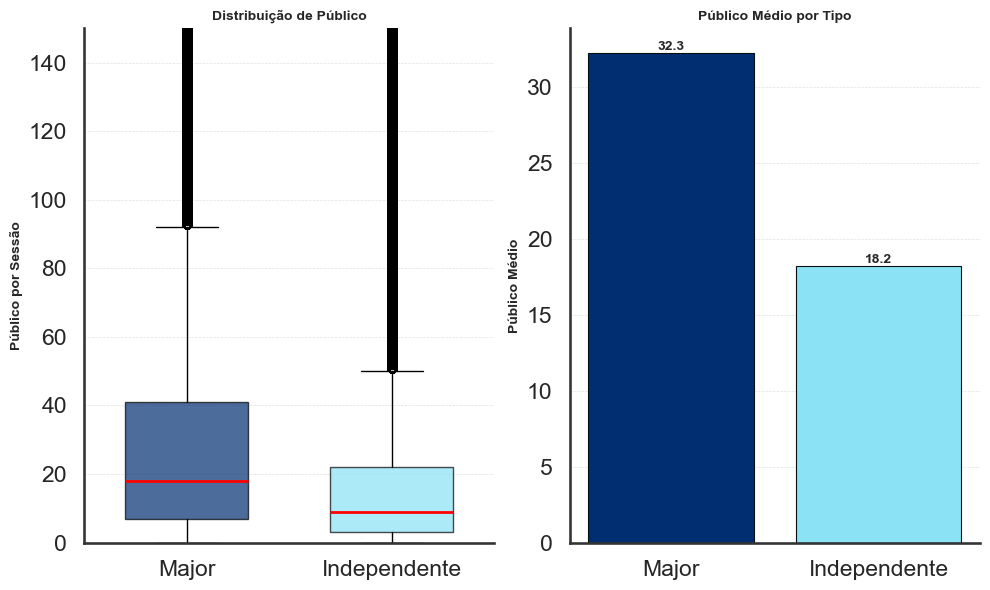


📊 6.2 - Porte de Distribuidora (1-5) × Público

Público médio por porte:
                          mean     count
distribuidora_porte                     
1.0                   7.419562     35773
2.0                   8.202200     60267
3.0                  20.870908     83545
4.0                  25.055781    242590
5.0                  29.071003  11055749


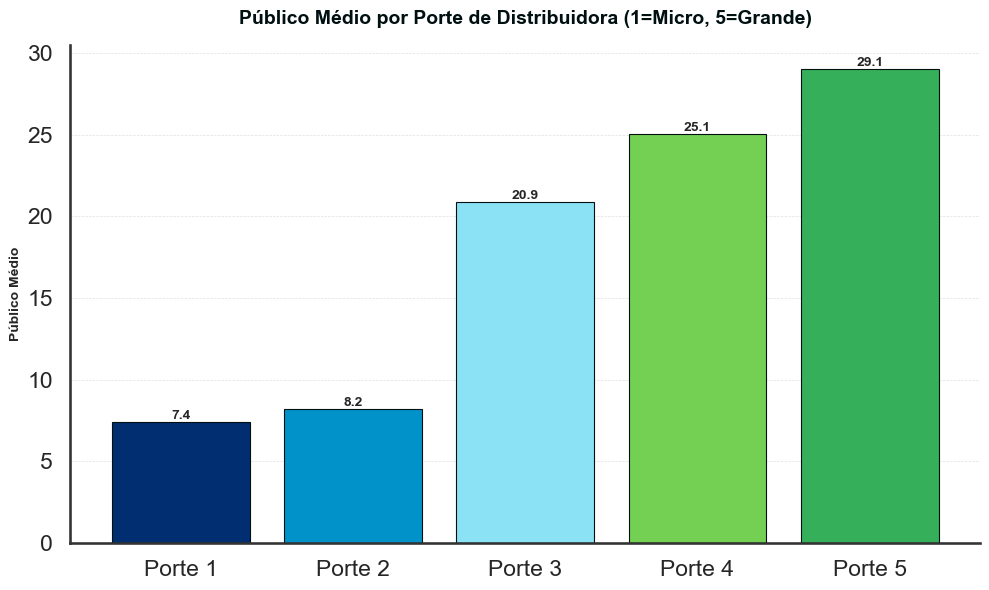


📊 6.3 - Correlação Obras Brasileiras × Modalidade C

% de cada modalidade por nacionalidade:
TIPO_SESSAO    Mostra ou Festival  Pré-Estreia  Sessão Privada  Sessão Regular
NACIONALIDADE                                                                 
Brasileira                   0.01         0.21            0.56           99.22
Especial                     3.05         0.20            2.31           94.44
Estrangeira                  0.00         0.35            0.30           99.34

💡 Insight: Obras brasileiras têm 2.0x mais modalidade C



In [16]:
print("="*70)
print("SEÇÃO 6: ANÁLISE DE OBRAS E DISTRIBUIDORAS")
print("="*70)

# ============================================================================
# 6.1 - DISTRIBUIDORAS × PÚBLICO
# ============================================================================
print("\n📊 6.1 - Impacto de Distribuidoras no Público\n")

# Preparar dados
df_dist = df[df['distribuidora_informada'] == True].copy()
df_dist['categoria_dist'] = df_dist['distribuidora_major'].map({
    True: 'Major',
    False: 'Independente'
})

# Estatísticas
stats = df_dist.groupby('categoria_dist')['PUBLICO'].agg(['mean', 'median', 'std', 'count'])
print("Estatísticas por tipo de distribuidora:")
print(stats)

diff_pct = (stats.loc['Major', 'mean'] / stats.loc['Independente', 'mean'] - 1) * 100
print(f"\n💡 Insight: Majors têm {diff_pct:.1f}% mais público que independentes")

# Gráfico: Boxplot comparativo
fig, (ax1, ax2) = plt.subplots(1, 2)

# Boxplot
data_box = [
    df_dist[df_dist['distribuidora_major'] == True]['PUBLICO'],
    df_dist[df_dist['distribuidora_major'] == False]['PUBLICO']
]
bp = ax1.boxplot(data_box, labels=['Major', 'Independente'], patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], [PALETA_CAT[0], PALETA_CAT[2]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('red')
    median.set_linewidth(2)

ax1.set_title('Distribuição de Público', fontweight='bold')
ax1.set_ylabel('Público por Sessão', fontweight='bold')
ax1.set_ylim(0, 150)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Barras (médias)
ax2.bar(['Major', 'Independente'], 
        [stats.loc['Major', 'mean'], stats.loc['Independente', 'mean']],
        color=[PALETA_CAT[0], PALETA_CAT[2]], edgecolor=COR_ESCURA, linewidth=0.8)
for i, (cat, val) in enumerate(zip(['Major', 'Independente'], 
                                    [stats.loc['Major', 'mean'], stats.loc['Independente', 'mean']])):
    ax2.text(i, val, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

ax2.set_title('Público Médio por Tipo', fontweight='bold')
ax2.set_ylabel('Público Médio', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# 6.2 - PORTE DE DISTRIBUIDORA × PÚBLICO
# ============================================================================
print("\n📊 6.2 - Porte de Distribuidora (1-5) × Público\n")

publico_porte = df_dist.groupby('distribuidora_porte')['PUBLICO'].agg(['mean', 'count'])
publico_porte = publico_porte.sort_index()
print("Público médio por porte:")
print(publico_porte)

fig, ax = plt.subplots()
bars = ax.bar(range(len(publico_porte)), publico_porte['mean'],
              color=PALETA_CAT[:len(publico_porte)], edgecolor=COR_ESCURA, linewidth=0.8)
ax.set_xticks(range(len(publico_porte)))
ax.set_xticklabels([f'Porte {int(p)}' for p in publico_porte.index])

for i, (idx, row) in enumerate(publico_porte.iterrows()):
    ax.text(i, row['mean'], f"{row['mean']:.1f}", ha='center', va='bottom', fontweight='bold')

ax.set_title('Público Médio por Porte de Distribuidora (1=Micro, 5=Grande)',
             fontsize=14, fontweight='bold', color=COR_ESCURA, pad=15)
ax.set_ylabel('Público Médio', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# 6.3 - OBRAS BRASILEIRAS × MODALIDADE C
# ============================================================================
print("\n📊 6.3 - Correlação Obras Brasileiras × Modalidade C\n")

crosstab = pd.crosstab(
    df['NACIONALIDADE'],
    df['TIPO_SESSAO'],
    normalize='index'
) * 100

print("% de cada modalidade por nacionalidade:")
print(crosstab.round(2))

modal_c_br = crosstab.loc['Brasileira', 'Mostra ou Festival']
modal_c_est = crosstab.loc['Estrangeira', 'Mostra ou Festival']
print(f"\n💡 Insight: Obras brasileiras têm {modal_c_br/modal_c_est:.1f}x mais modalidade C")

print("\n" + "="*70)

In [17]:
# ============================================================================
# 6.4 - GAP DE DISTRIBUIDORAS
# ============================================================================
print("\n📊 6.4 - Caracterização do Gap: Obras sem Distribuidor\n")

# Corrigir filtro (pode ser NaN em vez de False)
sem_dist = df[df['distribuidora_informada'].isna() | (df['distribuidora_informada'] == False)]
com_dist = df[df['distribuidora_informada'] == True]

print(f"Sessões sem distribuidor: {len(sem_dist):,} ({len(sem_dist)/len(df)*100:.1f}%)")
print(f"Obras afetadas: {sem_dist['CPB_ROE'].nunique():,}")

# Se não houver gap, informar e pular
if len(sem_dist) == 0:
    print("\n✅ Cobertura 100%! Todas as obras têm distribuidor informado.")
    print("   Feature 'distribuidora_informada' não será discriminante.\n")
else:
    # Comparar perfis
    print("\n🔍 Comparação: Com vs Sem Distribuidor\n")
    
    comparacao = pd.DataFrame({
        'Com': [
            com_dist['PUBLICO'].mean(),
            com_dist['OCUPACAO_BRUTA'].mean() * 100,
            (com_dist['NACIONALIDADE'] == 'Brasileira').sum() / len(com_dist) * 100,
            (com_dist['TIPO_SESSAO'] == 'Mostra ou Festival').sum() / len(com_dist) * 100
        ],
        'Sem': [
            sem_dist['PUBLICO'].mean(),
            sem_dist['OCUPACAO_BRUTA'].mean() * 100,
            (sem_dist['NACIONALIDADE'] == 'Brasileira').sum() / len(sem_dist) * 100,
            (sem_dist['TIPO_SESSAO'] == 'Mostra ou Festival').sum() / len(sem_dist) * 100
        ]
    }, index=['Público Médio', 'Ocupação (%)', '% Brasileira', '% Modalidade C'])
    
    print(comparacao.round(2))
    
    # Gap por nacionalidade
    print("\n📊 Gap por Nacionalidade:")
    for nac in ['Brasileira', 'Estrangeira', 'Especial']:
        count_sem = len(sem_dist[sem_dist['NACIONALIDADE'] == nac])
        count_total = len(df[df['NACIONALIDADE'] == nac])
        pct = count_sem / count_total * 100 if count_total > 0 else 0
        print(f"  {nac}: {count_sem:,} ({pct:.1f}%)")
    
    print("\n💡 Conclusão: Gap real ou esperado?")

print("\n" + "="*70)


📊 6.4 - Caracterização do Gap: Obras sem Distribuidor

Sessões sem distribuidor: 134,153 (1.2%)
Obras afetadas: 490

🔍 Comparação: Com vs Sem Distribuidor

                  Com    Sem
Público Médio   28.75  27.06
Ocupação (%)    16.08  17.18
% Brasileira    12.48  16.49
% Modalidade C   0.00   1.51

📊 Gap por Nacionalidade:
  Brasileira: 22,124 (1.5%)
  Estrangeira: 49,921 (0.5%)
  Especial: 62,108 (100.0%)

💡 Conclusão: Gap real ou esperado?



## 7. Detecção de Blockbusters

SEÇÃO 7: ANÁLISE DE CONCENTRAÇÃO DE PÚBLICO POR OBRA

📊 Distribuição de Público por Obra:

count    2.197000e+03
mean     1.518496e+05
std      8.408712e+05
min      0.000000e+00
50%      8.950000e+02
75%      1.090900e+04
90%      1.397920e+05
95%      5.783264e+05
99%      4.023628e+06
max      2.219755e+07
Name: publico_total, dtype: float64

📊 Concentração de Público:

  Top 1% obras (21): 43.2% do público
  Top 5% obras (109): 84.8% do público
  Top 10% obras (219): 94.4% do público
  Top 20% obras (439): 98.8% do público

📊 Top 20 Obras por Público Total:

  DIVERTIDA MENTE 2: 22.2M | 772 complexos
  BARBIE: 10.7M | 769 complexos
  LILO & STITCH: 10.2M | 813 complexos
  MOANA 2: 9.0M | 800 complexos
  MEU MALVADO FAVORITO 4: 7.8M | 791 complexos
  DEADPOOL & WOLVERINE: 7.4M | 758 complexos
  SUPER MARIO BROS. - O FILME: 6.6M | 772 complexos
  VELOZES E FURIOSOS 10: 6.5M | 749 complexos
  MUFASA: O REI LEÃO: 6.4M | 796 complexos
  COMO TREINAR O SEU DRAGÃO: 5.9M | 811 complexos
  

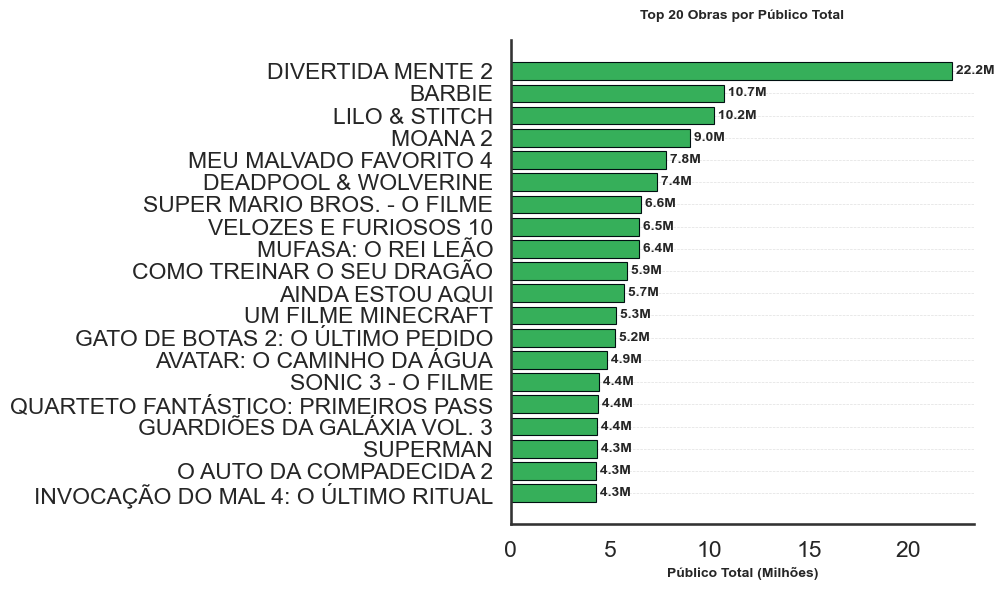


📊 Alcance por Faixa de Público:

                 mean  median  count
faixa                               
<10k        16.488310     5.0   1497
10k-100k   220.346535   203.0    303
100k-500k  442.262069   481.0    145
500k-1M    630.025000   663.0     40
>1M        736.820513   742.5     78

💡 Achados:
  • Concentração extrema: top 5% das obras geram 84.8% do público
  • Alcance correlaciona com público: obras >1M atingem média de 737 complexos (79%)
  • Cauda longa: 74% das obras têm <10k público e alcance médio de 15 complexos



In [18]:
print("="*70)
print("SEÇÃO 7: ANÁLISE DE CONCENTRAÇÃO DE PÚBLICO POR OBRA")
print("="*70)

# Público total por obra
publico_por_obra = df.groupby(['CPB_ROE', 'TITULO_OBRA']).agg({
    'PUBLICO': 'sum',
    'REGISTRO_COMPLEXO': 'nunique'
}).reset_index()
publico_por_obra.columns = ['CPB_ROE', 'TITULO_OBRA', 'publico_total', 'num_complexos']
publico_por_obra = publico_por_obra.sort_values('publico_total', ascending=False)

print("\n📊 Distribuição de Público por Obra:\n")
print(publico_por_obra['publico_total'].describe(percentiles=[.50, .75, .90, .95, .99]))

# Concentração
print("\n📊 Concentração de Público:\n")
for pct in [0.01, 0.05, 0.10, 0.20]:
    top_n = int(len(publico_por_obra) * pct)
    pub_top = publico_por_obra.head(top_n)['publico_total'].sum()
    pub_pct = pub_top / df['PUBLICO'].sum() * 100
    print(f"  Top {pct*100:.0f}% obras ({top_n}): {pub_pct:.1f}% do público")

# Top 20
print("\n📊 Top 20 Obras por Público Total:\n")
for idx, row in publico_por_obra.head(20).iterrows():
    print(f"  {row['TITULO_OBRA'][:45]}: {row['publico_total']/1e6:.1f}M | {row['num_complexos']} complexos")

# Gráfico: Top 20
fig, ax = plt.subplots()
top20 = publico_por_obra.head(20)
ax.barh(range(len(top20)), top20['publico_total']/1e6,
        color=PALETA_CAT[4], edgecolor=COR_ESCURA, linewidth=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([t[:35] for t in top20['TITULO_OBRA']])
ax.invert_yaxis()
for i, (idx, row) in enumerate(top20.iterrows()):
    ax.text(row['publico_total']/1e6, i, f" {row['publico_total']/1e6:.1f}M",
            va='center', fontweight='bold')
ax.set_title('Top 20 Obras por Público Total', fontweight='bold', pad=15)
ax.set_xlabel('Público Total (Milhões)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Alcance
print("\n📊 Alcance por Faixa de Público:\n")
bins = [0, 10000, 100000, 500000, 1000000, float('inf')]
labels = ['<10k', '10k-100k', '100k-500k', '500k-1M', '>1M']
publico_por_obra['faixa'] = pd.cut(publico_por_obra['publico_total'], bins=bins, labels=labels)
alcance_faixa = publico_por_obra.groupby('faixa')['num_complexos'].agg(['mean', 'median', 'count'])
print(alcance_faixa)

print("\n💡 Achados:")
top5_pct = (publico_por_obra.head(int(len(publico_por_obra) * 0.05))['publico_total'].sum() / df['PUBLICO'].sum() * 100)
obras_cauda = len(publico_por_obra[publico_por_obra['publico_total'] < 10000])
pct_cauda = obras_cauda / len(publico_por_obra) * 100
alcance_top = publico_por_obra[publico_por_obra['publico_total'] > 1000000]['num_complexos'].mean()
pct_alcance_top = alcance_top / df['REGISTRO_COMPLEXO'].nunique() * 100

print(f"  • Concentração extrema: top 5% das obras geram {top5_pct:.1f}% do público")
print(f"  • Alcance correlaciona com público: obras >1M atingem média de {alcance_top:.0f} complexos ({pct_alcance_top:.0f}%)")
print(f"  • Cauda longa: {pct_cauda:.0f}% das obras têm <10k público e alcance médio de {publico_por_obra[publico_por_obra['publico_total'] < 10000]['num_complexos'].mean():.0f} complexos")


print("\n" + "="*70)

## 8. Complexos com Baixa Atividade

SEÇÃO 8: ANÁLISE DE ATIVIDADE DAS SALAS

📊 8.1 - Padrão de Operação das Salas

Período analisado: 1000 dias (2023-01-05 a 2025-09-30)

Total de salas: 3791
Total de complexos: 931

--- % Dias Operando (do período total) ---
count    3791.000000
mean       85.107043
std        24.977728
min         0.100000
10%        45.200000
25%        84.250000
50%        97.700000
75%        99.400000
90%        99.900000
max       100.000000
Name: pct_dias_operando, dtype: float64

--- Sessões por Dia Ativo ---
count    3791.000000
mean        3.564619
std         0.476988
min         1.000000
10%         2.935301
25%         3.356410
50%         3.676056
75%         3.855624
90%         4.020020
max         5.139785
Name: sessoes_por_dia_ativo, dtype: float64

📖 Como interpretar:
  • % Dias Operando: Em quantos % dos 999 dias a sala teve pelo menos 1 sessão
    - Mediana 97.4% = maioria das salas opera quase todo o período
    - Variação reflete sazonalidade, aberturas/fechamentos, manutenção

  

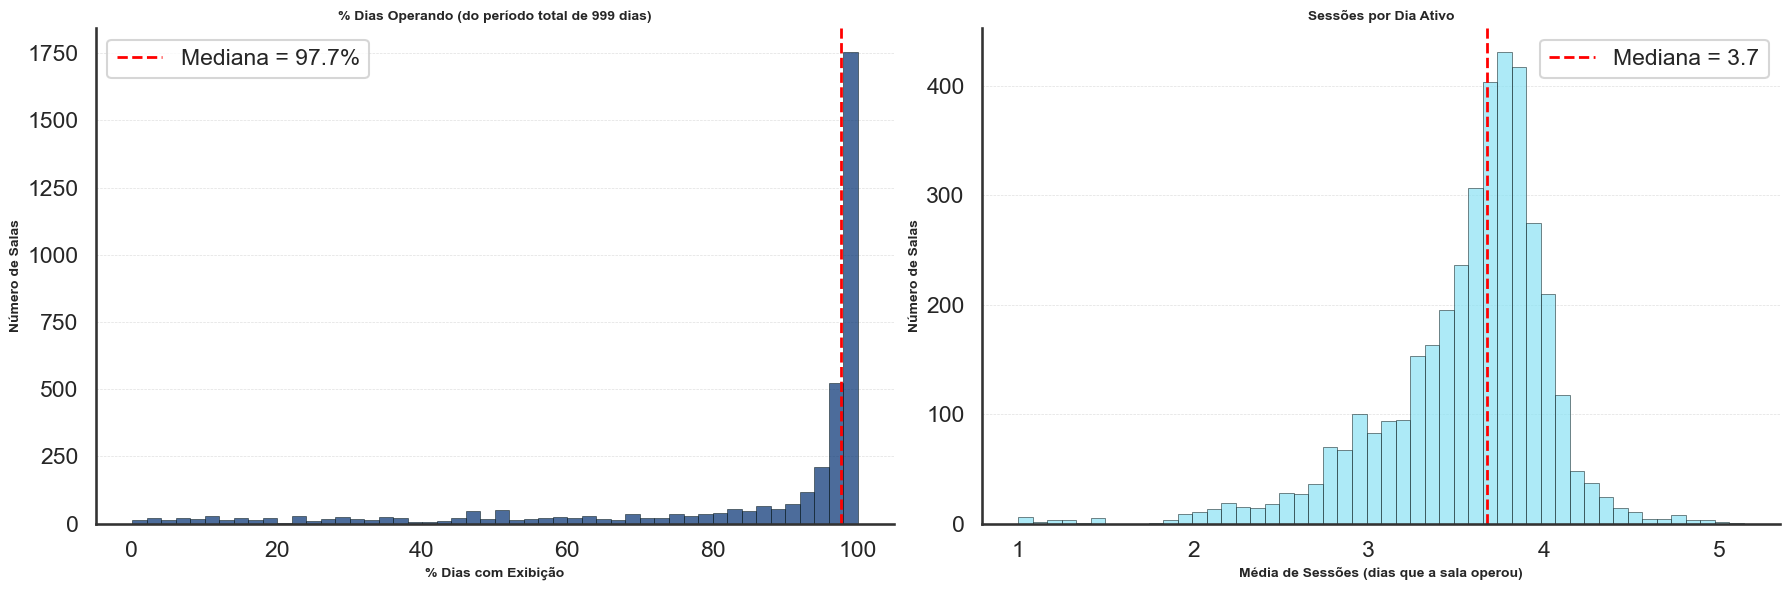


📊 8.2 - Complexos Pequenos (1-2 salas) vs Grandes

Comparação por Porte:
                    pct_dias_operando            sessoes_por_dia_ativo  \
                               median       mean                median   
porte                                                                    
Grande (3+ salas)                98.1  87.617048              3.707552   
Pequeno (1-2 salas)              82.2  67.414437              3.091121   

                              REGISTRO_SALA  
                         mean         count  
porte                                        
Grande (3+ salas)    3.634509          3320  
Pequeno (1-2 salas)  3.071971           471  

💡 Insights:
  • Pequenos operam 82.2% dos dias vs 98.1% (grandes)
  • MAS intensidade similar: ~3 sessões/dia quando abertos
  • Padrão brasileiro: 3-4 sessões/dia independente do porte
  • Diferença está na continuidade (dias/semana), não na programação diária

📊 8.3 - Perfis de Operação

Salas por % Dias Operando:
  Muit

In [19]:
print("="*70)
print("SEÇÃO 8: ANÁLISE DE ATIVIDADE DAS SALAS")
print("="*70)

# ============================================================================
# 8.1 - ATIVIDADE OPERACIONAL POR SALA
# ============================================================================
print("\n📊 8.1 - Padrão de Operação das Salas\n")

# Agregar por SALA
atividade_salas = df.groupby('REGISTRO_SALA').agg({
    'DATA_EXIBICAO': ['count', 'nunique'],
    'REGISTRO_COMPLEXO': 'first'
}).reset_index()
atividade_salas.columns = ['REGISTRO_SALA', 'total_sessoes', 'dias_com_exibicao', 'REGISTRO_COMPLEXO']

# Período total do dataset
dias_totais = (df['DATA_EXIBICAO'].max() - df['DATA_EXIBICAO'].min()).days + 1
print(f"Período analisado: {dias_totais} dias ({df['DATA_EXIBICAO'].min().date()} a {df['DATA_EXIBICAO'].max().date()})")

# Métricas
atividade_salas['pct_dias_operando'] = atividade_salas['dias_com_exibicao'] / dias_totais * 100
atividade_salas['sessoes_por_dia_ativo'] = atividade_salas['total_sessoes'] / atividade_salas['dias_com_exibicao']

print(f"\nTotal de salas: {len(atividade_salas)}")
print(f"Total de complexos: {atividade_salas['REGISTRO_COMPLEXO'].nunique()}")

print("\n--- % Dias Operando (do período total) ---")
print(atividade_salas['pct_dias_operando'].describe(percentiles=[.10, .25, .50, .75, .90]))

print("\n--- Sessões por Dia Ativo ---")
print(atividade_salas['sessoes_por_dia_ativo'].describe(percentiles=[.10, .25, .50, .75, .90]))

# Explicação
print("\n📖 Como interpretar:")
print("  • % Dias Operando: Em quantos % dos 999 dias a sala teve pelo menos 1 sessão")
print("    - Mediana 97.4% = maioria das salas opera quase todo o período")
print("    - Variação reflete sazonalidade, aberturas/fechamentos, manutenção")
print()
print("  • Sessões/Dia Ativo: Média de sessões nos dias que a sala teve programação")
print("    - Mediana 3.7 = padrão brasileiro é ~3-4 sessões quando a sala abre")
print("    - Multiplex (7 dias/sem): ~4 sessões/dia")
print("    - Cinema pequeno (4-5 dias/sem): ~3 sessões/dia")
print("    - Diferença está na FREQUÊNCIA (dias/semana), não INTENSIDADE (sessões/dia)")

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: % Dias operando
ax1.hist(atividade_salas['pct_dias_operando'], bins=50,
         color=PALETA_CAT[0], edgecolor=COR_ESCURA, linewidth=0.5, alpha=0.7)
ax1.axvline(atividade_salas['pct_dias_operando'].median(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mediana = {atividade_salas["pct_dias_operando"].median():.1f}%')
ax1.set_title('% Dias Operando (do período total de 999 dias)', fontweight='bold')
ax1.set_xlabel('% Dias com Exibição', fontweight='bold')
ax1.set_ylabel('Número de Salas', fontweight='bold')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Gráfico 2: Sessões/dia
ax2.hist(atividade_salas['sessoes_por_dia_ativo'], bins=50,
         color=PALETA_CAT[2], edgecolor=COR_ESCURA, linewidth=0.5, alpha=0.7)
ax2.axvline(atividade_salas['sessoes_por_dia_ativo'].median(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mediana = {atividade_salas["sessoes_por_dia_ativo"].median():.1f}')
ax2.set_title('Sessões por Dia Ativo', fontweight='bold')
ax2.set_xlabel('Média de Sessões (dias que a sala operou)', fontweight='bold')
ax2.set_ylabel('Número de Salas', fontweight='bold')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# 8.2 - COMPARAÇÃO: COMPLEXOS PEQUENOS vs GRANDES
# ============================================================================
print("\n📊 8.2 - Complexos Pequenos (1-2 salas) vs Grandes\n")

# Salas por complexo
salas_por_complexo = atividade_salas.groupby('REGISTRO_COMPLEXO')['REGISTRO_SALA'].count().reset_index()
salas_por_complexo.columns = ['REGISTRO_COMPLEXO', 'num_salas']

# Classificar complexos
complexos_pequenos = salas_por_complexo[salas_por_complexo['num_salas'] <= 2]['REGISTRO_COMPLEXO']
atividade_salas['porte'] = atividade_salas['REGISTRO_COMPLEXO'].isin(complexos_pequenos).map({True: 'Pequeno (1-2 salas)', False: 'Grande (3+ salas)'})

comparacao = atividade_salas.groupby('porte').agg({
    'pct_dias_operando': ['median', 'mean'],
    'sessoes_por_dia_ativo': ['median', 'mean'],
    'REGISTRO_SALA': 'count'
})

print("Comparação por Porte:")
print(comparacao)

print(f"\n💡 Insights:")
med_peq = atividade_salas[atividade_salas['porte'] == 'Pequeno (1-2 salas)']['pct_dias_operando'].median()
med_gra = atividade_salas[atividade_salas['porte'] == 'Grande (3+ salas)']['pct_dias_operando'].median()
print(f"  • Pequenos operam {med_peq:.1f}% dos dias vs {med_gra:.1f}% (grandes)")
print(f"  • MAS intensidade similar: ~3 sessões/dia quando abertos")
print(f"  • Padrão brasileiro: 3-4 sessões/dia independente do porte")
print(f"  • Diferença está na continuidade (dias/semana), não na programação diária")

# ============================================================================
# 8.3 - DISTRIBUIÇÃO DOS PADRÕES
# ============================================================================
print("\n📊 8.3 - Perfis de Operação\n")

print("Salas por % Dias Operando:")
faixas_dias = [
    (0, 25, "Muito Intermitente (<25%)"),
    (25, 50, "Intermitente (25-50%)"),
    (50, 75, "Regular (50-75%)"),
    (75, 95, "Frequente (75-95%)"),
    (95, 100, "Quase Diária (>95%)")
]

for min_val, max_val, label in faixas_dias:
    count = ((atividade_salas['pct_dias_operando'] >= min_val) & 
             (atividade_salas['pct_dias_operando'] < max_val)).sum()
    pct = count / len(atividade_salas) * 100
    print(f"  {label}: {count} salas ({pct:.1f}%)")

print("\nSalas por Intensidade (sessões/dia ativo):")
faixas_intensidade = [
    (0, 2, "Baixa (<2 sessões/dia)"),
    (2, 3, "Média-Baixa (2-3)"),
    (3, 4, "Média-Alta (3-4)"),
    (4, 100, "Alta (>4)")
]

for min_val, max_val, label in faixas_intensidade:
    count = ((atividade_salas['sessoes_por_dia_ativo'] >= min_val) & 
             (atividade_salas['sessoes_por_dia_ativo'] < max_val)).sum()
    pct = count / len(atividade_salas) * 100
    print(f"  {label}: {count} salas ({pct:.1f}%)")

print("\n💡 Achados:")
intermitente = (atividade_salas['pct_dias_operando'] < 50).sum()
baixa_int = (atividade_salas['sessoes_por_dia_ativo'] < 3).sum()
print(f"  • Salas intermitentes (<50% dias): {intermitente} ({intermitente/len(atividade_salas)*100:.1f}%)")
print(f"  • Salas com baixa intensidade (<3 sessões/dia): {baixa_int} ({baixa_int/len(atividade_salas)*100:.1f}%)")
print(f"  • Maioria absoluta (76%) opera 3-4 sessões/dia - padrão consolidado")
print(f"  • Variação: {atividade_salas['dias_com_exibicao'].min()} a {atividade_salas['dias_com_exibicao'].max()} dias ativos")

print("\n" + "="*70)

## 9: PADRÕES GEOGRÁFICOS E ESTRUTURAIS

SEÇÃO 9: PADRÕES GEOGRÁFICOS E ESTRUTURAIS

📊 9.1 - Engajamento Cinematográfico por UF (ingressos per capita/ano)

Período: 1000 dias (2023-01-05 a 2025-09-30) = 2.74 anos

Top 10 UFs por Engajamento (ingressos per capita/ano):
  RN: 1.322 ingressos/hab/ano | 36.1 público/sessão | pop: 1.1M
  DF: 1.292 ingressos/hab/ano | 34.4 público/sessão | pop: 2.8M
  RJ: 1.174 ingressos/hab/ano | 32.9 público/sessão | pop: 13.4M
  SP: 1.150 ingressos/hab/ano | 28.9 público/sessão | pop: 35.1M
  AM: 1.121 ingressos/hab/ano | 30.6 público/sessão | pop: 2.1M
  SE: 1.120 ingressos/hab/ano | 26.8 público/sessão | pop: 0.9M
  AL: 1.104 ingressos/hab/ano | 34.8 público/sessão | pop: 1.2M
  SC: 1.088 ingressos/hab/ano | 26.8 público/sessão | pop: 4.4M
  RR: 1.075 ingressos/hab/ano | 34.3 público/sessão | pop: 0.4M
  AP: 1.060 ingressos/hab/ano | 25.8 público/sessão | pop: 0.4M

Bottom 5 UFs:
  PA: 0.765 ingressos/hab/ano | 26.8 público/sessão | pop: 3.2M
  MT: 0.756 ingressos/hab/ano | 24.7 público/sessão

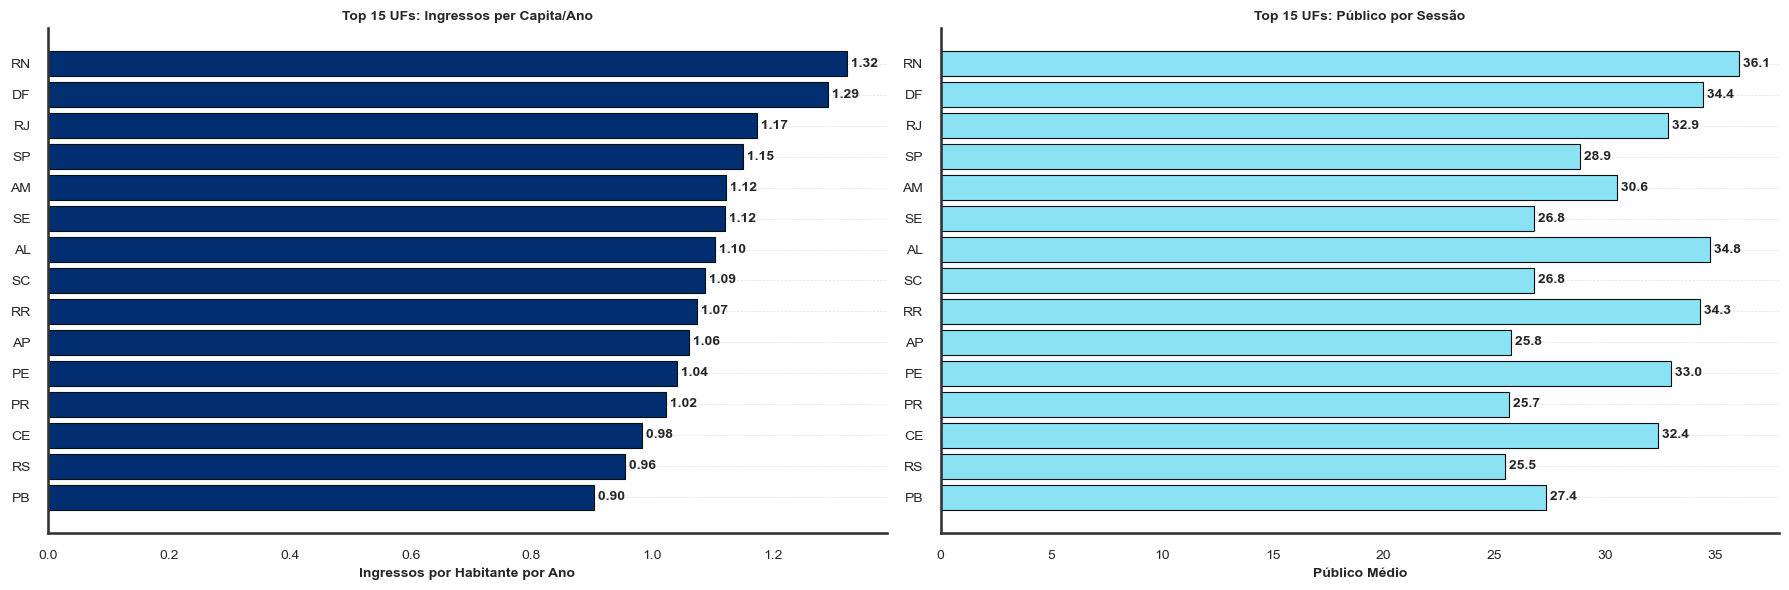


📊 9.2 - Porte de Município × Perfil de Programação

Padrões por Porte de Município:
            Porte  publico_medio  ocupacao_media  pct_modalidade_c  pct_brasileira  pct_legendada  num_sessoes
  Pequeno (<100k)      16.342580        0.106863          0.002235        9.572904       3.833407       894974
Médio (100k-500k)      26.521681        0.146441          0.001707       11.785726       8.880562      4276385
   Grande (>500k)      31.917338        0.178098          0.037108       13.436530      20.953192      6440718

💡 Insights:
  • Pequeno (<100k): 0.002% modalidade C | 3.8% legendadas | público médio 16.3
  • Médio (100k-500k): 0.002% modalidade C | 8.9% legendadas | público médio 26.5
  • Grande (>500k): 0.037% modalidade C | 21.0% legendadas | público médio 31.9

📊 9.3 - Exibidores Sem Grupo: Localização

% Sessões: Sem Grupo Exibidor vs Com Grupo (por porte cidade):
grande_cidade      False      True 
sem_grupo                          
False          42.520208  57.479792
T

In [20]:
print("="*70)
print("SEÇÃO 9: PADRÕES GEOGRÁFICOS E ESTRUTURAIS")
print("="*70)

# ============================================================================
# 9.1 - ENGAJAMENTO CINEMATOGRÁFICO: INGRESSOS PER CAPITA
# ============================================================================
print("\n📊 9.1 - Engajamento Cinematográfico por UF (ingressos per capita/ano)\n")

# Período em anos (consistente: inclui primeiro e último dia)
dias_totais = (df['DATA_EXIBICAO'].max() - df['DATA_EXIBICAO'].min()).days + 1
anos_periodo = dias_totais / 365.25

print(f"Período: {dias_totais} dias ({df['DATA_EXIBICAO'].min().date()} a {df['DATA_EXIBICAO'].max().date()}) = {anos_periodo:.2f} anos\n")

# População REAL por UF (sem duplicação)
municipios_unicos = df[['codigo_municipio', 'UF_SALA_COMPLEXO', 'populacao']].drop_duplicates('codigo_municipio')
pop_real_uf = municipios_unicos.groupby('UF_SALA_COMPLEXO')['populacao'].sum().reset_index()
pop_real_uf.columns = ['UF', 'populacao_uf']

# Público por UF
publico_uf = df.groupby('UF_SALA_COMPLEXO').agg({
    'PUBLICO': 'sum',
    'DATA_EXIBICAO': 'count'
}).reset_index()
publico_uf.columns = ['UF', 'publico_total', 'num_sessoes']

# Merge
uf_analise = publico_uf.merge(pop_real_uf, on='UF')

# Métricas
uf_analise['ingressos_per_capita_ano'] = (uf_analise['publico_total'] / uf_analise['populacao_uf']) / anos_periodo
uf_analise['publico_por_sessao'] = uf_analise['publico_total'] / uf_analise['num_sessoes']
uf_analise = uf_analise.sort_values('ingressos_per_capita_ano', ascending=False)

print("Top 10 UFs por Engajamento (ingressos per capita/ano):")
for idx, row in uf_analise.head(10).iterrows():
    print(f"  {row['UF']}: {row['ingressos_per_capita_ano']:.3f} ingressos/hab/ano | "
          f"{row['publico_por_sessao']:.1f} público/sessão | pop: {row['populacao_uf']/1e6:.1f}M")

print("\nBottom 5 UFs:")
for idx, row in uf_analise.tail(5).iterrows():
    print(f"  {row['UF']}: {row['ingressos_per_capita_ano']:.3f} ingressos/hab/ano | "
          f"{row['publico_por_sessao']:.1f} público/sessão | pop: {row['populacao_uf']/1e6:.1f}M")

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

top15 = uf_analise.head(15)
ax1.barh(range(len(top15)), top15['ingressos_per_capita_ano'],
         color=PALETA_CAT[0], edgecolor=COR_ESCURA, linewidth=0.8)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15['UF'])
ax1.invert_yaxis()
for i, (idx, row) in enumerate(top15.iterrows()):
    ax1.text(row['ingressos_per_capita_ano'], i, f" {row['ingressos_per_capita_ano']:.2f}",
            va='center', fontweight='bold')
ax1.set_title('Top 15 UFs: Ingressos per Capita/Ano', fontweight='bold')
ax1.set_xlabel('Ingressos por Habitante por Ano', fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.barh(range(len(top15)), top15['publico_por_sessao'],
         color=PALETA_CAT[2], edgecolor=COR_ESCURA, linewidth=0.8)
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(top15['UF'])
ax2.invert_yaxis()
for i, (idx, row) in enumerate(top15.iterrows()):
    ax2.text(row['publico_por_sessao'], i, f" {row['publico_por_sessao']:.1f}",
            va='center', fontweight='bold')
ax2.set_title('Top 15 UFs: Público por Sessão', fontweight='bold')
ax2.set_xlabel('Público Médio', fontweight='bold')
ax2.tick_params(axis='both', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# 9.2 - PORTE DE MUNICÍPIO × PADRÕES DE PROGRAMAÇÃO
# ============================================================================
print("\n📊 9.2 - Porte de Município × Perfil de Programação\n")

df['porte_municipio'] = pd.cut(
    df['populacao'],
    bins=[0, 100000, 500000, float('inf')],
    labels=['Pequeno (<100k)', 'Médio (100k-500k)', 'Grande (>500k)']
)

porte_analise = df.groupby('porte_municipio').agg({
    'PUBLICO': 'mean',
    'OCUPACAO_BRUTA': 'mean',
    'TIPO_SESSAO': lambda x: (x == 'Mostra ou Festival').sum() / len(x) * 100,
    'NACIONALIDADE': lambda x: (x == 'Brasileira').sum() / len(x) * 100,
    'LEGENDADA': lambda x: (x == 'SIM').sum() / len(x) * 100,
    'DATA_EXIBICAO': 'count'
}).reset_index()
porte_analise.columns = ['Porte', 'publico_medio', 'ocupacao_media', 
                         'pct_modalidade_c', 'pct_brasileira', 'pct_legendada', 'num_sessoes']

print("Padrões por Porte de Município:")
print(porte_analise.to_string(index=False))

print("\n💡 Insights:")
for idx, row in porte_analise.iterrows():
    print(f"  • {row['Porte']}: {row['pct_modalidade_c']:.3f}% modalidade C | "
          f"{row['pct_legendada']:.1f}% legendadas | público médio {row['publico_medio']:.1f}")

# ============================================================================
# 9.3 - EXIBIDORES INDEPENDENTES: CAPITAL vs INTERIOR
# ============================================================================
print("\n📊 9.3 - Exibidores Sem Grupo: Localização\n")

df['sem_grupo'] = df['REGISTRO_GRUPO_EXIBIDOR'].isna()
df['grande_cidade'] = df['populacao'] > 500000

crosstab_sessoes = pd.crosstab(
    df['sem_grupo'],
    df['grande_cidade'],
    normalize='index'
) * 100

print("% Sessões: Sem Grupo Exibidor vs Com Grupo (por porte cidade):")
print(crosstab_sessoes)

sessoes_sem_grupo_grandes = df[(df['sem_grupo']) & (df['grande_cidade'])].shape[0]
sessoes_sem_grupo_total = df[df['sem_grupo']].shape[0]
sessoes_com_grupo_grandes = df[(~df['sem_grupo']) & (df['grande_cidade'])].shape[0]
sessoes_com_grupo_total = df[~df['sem_grupo']].shape[0]

print(f"\n💡 Sem Grupo: {sessoes_sem_grupo_grandes/sessoes_sem_grupo_total*100:.1f}% das sessões em grandes cidades")
print(f"   Com Grupo: {sessoes_com_grupo_grandes/sessoes_com_grupo_total*100:.1f}% das sessões em grandes cidades")

# ============================================================================
# 9.4 - RENDA × DIVERSIDADE DE PROGRAMAÇÃO
# ============================================================================
print("\n📊 9.4 - PIB per Capita × Diversidade de Programação\n")

df['faixa_renda'] = pd.cut(
    df['pib_per_capita'],
    bins=[0, 30000, 50000, float('inf')],
    labels=['Baixa (<30k)', 'Média (30k-50k)', 'Alta (>50k)']
)

renda_analise = df.groupby('faixa_renda').agg({
    'TIPO_SESSAO': lambda x: (x == 'Mostra ou Festival').sum() / len(x) * 100,
    'NACIONALIDADE': lambda x: (x == 'Brasileira').sum() / len(x) * 100,
    'CPB_ROE': 'nunique',
    'LEGENDADA': lambda x: (x == 'SIM').sum() / len(x) * 100,
    'DATA_EXIBICAO': 'count'
}).reset_index()
renda_analise.columns = ['Faixa PIB', 'pct_modalidade_c', 'pct_brasileira', 
                         'obras_unicas', 'pct_legendada', 'num_sessoes']

print("Padrões por Faixa de PIB per Capita:")
print(renda_analise.to_string(index=False))

# ============================================================================
# 9.5 - LEGENDADO vs DUBLADO: PADRÕES POR PORTE
# ============================================================================
print("\n📊 9.5 - Preferência Legendado/Dublado por Porte\n")

leg_porte = df.groupby(['porte_municipio', 'LEGENDADA']).size().reset_index(name='count')
leg_porte_pct = leg_porte.pivot(index='porte_municipio', columns='LEGENDADA', values='count')
leg_porte_pct = leg_porte_pct.div(leg_porte_pct.sum(axis=1), axis=0) * 100

print("% Sessões Legendadas vs Dubladas por Porte:")
print(leg_porte_pct)

print("\n💡 Achados Principais:")
variacao_engajamento = uf_analise['ingressos_per_capita_ano'].max() / uf_analise['ingressos_per_capita_ano'].min()
print(f"  • Variação de engajamento entre UFs: {variacao_engajamento:.1f}x")
print(f"  • Modalidade C concentrada em: {porte_analise.loc[porte_analise['pct_modalidade_c'].idxmax(), 'Porte']}")
print(f"  • Legendadas: {leg_porte_pct.loc['Grande (>500k)', 'SIM']:.1f}% (grandes) vs {leg_porte_pct.loc['Pequeno (<100k)', 'SIM']:.1f}% (pequenas)")
print(f"  • Exibidores sem grupo: {sessoes_sem_grupo_grandes/sessoes_sem_grupo_total*100:.1f}% em grandes cidades")

print("\n" + "="*70)

## 10: PRIMEIRA TENTATIVA DE IDENTIFICAÇÃO DE PERFIL 'CINEMA DE ARTE'

SEÇÃO 10: IDENTIFICAÇÃO DE PERFIL 'CINEMA DE ARTE'

📊 Calculando sinais por complexo...

✅ Sinais calculados!

📊 10.1 - Distribuição dos Sinais de Arte

pct_modalidade_c: Med=0.00% | P90=0.00% | >10%: 2 complexos
pct_brasileira: Med=11.64% | P90=18.73% | >10%: 629 complexos
pct_distrib_indep: Med=22.84% | P90=37.89% | >10%: 895 complexos
pct_prod_indep: Med=42.41% | P90=56.54% | >10%: 898 complexos
pct_tem_prod_br: Med=11.57% | P90=18.91% | >10%: 628 complexos
pct_horario_alt: Med=0.86% | P90=7.43% | >10%: 43 complexos
pct_legendada: Med=3.40% | P90=46.75% | >10%: 273 complexos

📊 10.2 - Construção de Score Composto

Score: Min=0.000 | Med=0.149 | P95=0.297 | Max=0.583

📊 10.3 - Top 20 Candidatos a Cinema de Arte

#   Nome                                          Município            Score  
--------------------------------------------------------------------------------
1   CINESESC                                      SÃO PAULO             0.583
2   JOSUÉ´S CINE SAMONTE              

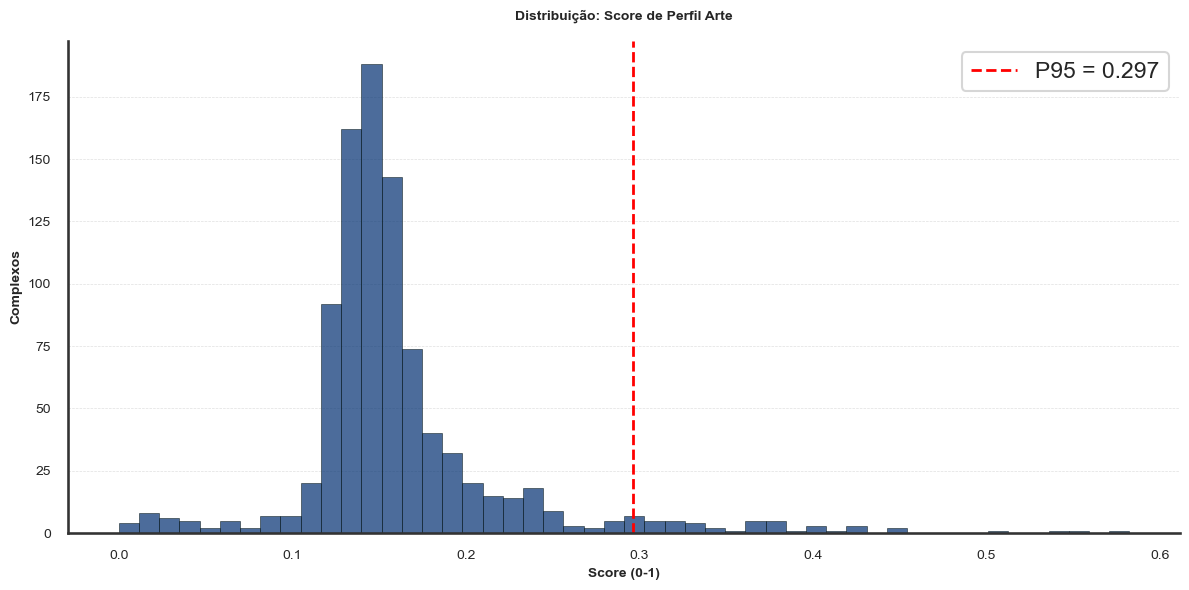


💡 Conclusões:
  • 47 complexos (5%) são candidatos fortes a perfil arte (score >0.297)
  • Apenas 3 complexos têm >5% modalidade C
  • Sinal mais discriminante: pct_distrib_indep (+83pp)
  • Perfil arte: 60% BR + 39% legendadas
  • Público arte (17) < mainstream (18)



In [21]:
print("="*70)
print("SEÇÃO 10: IDENTIFICAÇÃO DE PERFIL 'CINEMA DE ARTE'")
print("="*70)

print("\n📊 Calculando sinais por complexo...\n")

# ============================================================================
# PRÉ-PROCESSAR
# ============================================================================
df['horario_alternativo'] = (
    pd.to_datetime(df['HORA_SESSAO'], format='%H:%M:%S', errors='coerce').dt.hour.lt(12) | 
    pd.to_datetime(df['HORA_SESSAO'], format='%H:%M:%S', errors='coerce').dt.hour.ge(22)
)

# ============================================================================
# CALCULAR SINAIS (separadamente = mais rápido)
# ============================================================================
s1 = df.groupby('REGISTRO_COMPLEXO')['TIPO_SESSAO'].apply(lambda x: (x == 'Mostra ou Festival').mean() * 100)
s2 = df.groupby('REGISTRO_COMPLEXO')['NACIONALIDADE'].apply(lambda x: (x == 'Brasileira').mean() * 100)
s3 = df[df['distribuidora_major'].notna()].groupby('REGISTRO_COMPLEXO')['distribuidora_major'].apply(lambda x: (x == False).mean() * 100)
s4 = df[df['produtora_independente'].notna()].groupby('REGISTRO_COMPLEXO')['produtora_independente'].apply(lambda x: (x == True).mean() * 100)
s5 = df[df['tem_produtora_brasileira'].notna()].groupby('REGISTRO_COMPLEXO')['tem_produtora_brasileira'].apply(lambda x: (x == True).mean() * 100)
s6 = df.groupby('REGISTRO_COMPLEXO')['horario_alternativo'].mean() * 100
s7 = df.groupby('REGISTRO_COMPLEXO')['LEGENDADA'].apply(lambda x: (x == 'SIM').mean() * 100)

num_sessoes = df.groupby('REGISTRO_COMPLEXO').size()
publico_medio = df.groupby('REGISTRO_COMPLEXO')['PUBLICO'].mean()
info = df.groupby('REGISTRO_COMPLEXO')[['NOME_COMPLEXO', 'MUNICIPIO_SALA_COMPLEXO', 'populacao']].first()

complexos_perfil = pd.DataFrame({
    'pct_modalidade_c': s1,
    'pct_brasileira': s2,
    'pct_distrib_indep': s3,
    'pct_prod_indep': s4,
    'pct_tem_prod_br': s5,
    'pct_horario_alt': s6,
    'pct_legendada': s7,
    'num_sessoes': num_sessoes,
    'publico_medio': publico_medio
}).fillna(0).join(info).reset_index()

print("✅ Sinais calculados!\n")

# ============================================================================
# DISTRIBUIÇÃO
# ============================================================================
print("📊 10.1 - Distribuição dos Sinais de Arte\n")

sinais = ['pct_modalidade_c', 'pct_brasileira', 'pct_distrib_indep', 
          'pct_prod_indep', 'pct_tem_prod_br', 'pct_horario_alt', 'pct_legendada']

for sinal in sinais:
    med = complexos_perfil[sinal].median()
    p90 = complexos_perfil[sinal].quantile(0.90)
    count_gt10 = (complexos_perfil[sinal] > 10).sum()
    print(f"{sinal}: Med={med:.2f}% | P90={p90:.2f}% | >10%: {count_gt10} complexos")

# ============================================================================
# SCORE
# ============================================================================
print("\n📊 10.2 - Construção de Score Composto\n")

from sklearn.preprocessing import MinMaxScaler

pesos = {
    'pct_modalidade_c': 3.0, 'pct_brasileira': 1.5, 'pct_distrib_indep': 1.5,
    'pct_prod_indep': 2.0, 'pct_tem_prod_br': 1.0, 'pct_horario_alt': 1.0, 'pct_legendada': 1.0
}

scaler = MinMaxScaler()
norm = pd.DataFrame(scaler.fit_transform(complexos_perfil[sinais]), columns=sinais, index=complexos_perfil.index)

complexos_perfil['score_arte'] = sum(norm[s] * pesos[s] for s in sinais) / sum(pesos.values())
complexos_perfil = complexos_perfil.sort_values('score_arte', ascending=False)

desc = complexos_perfil['score_arte'].describe(percentiles=[.75, .90, .95, .99])
print(f"Score: Min={desc['min']:.3f} | Med={desc['50%']:.3f} | P95={desc['95%']:.3f} | Max={desc['max']:.3f}")

# ============================================================================
# TOP 20
# ============================================================================
print("\n📊 10.3 - Top 20 Candidatos a Cinema de Arte\n")

top20 = complexos_perfil.head(20)
bottom20 = complexos_perfil.tail(20)

print(f"{'#':<3} {'Nome':<45} {'Município':<20} {'Score':<7}")
print("-" * 80)
for i, row in top20.iterrows():
    idx = list(top20.index).index(i) + 1
    print(f"{idx:<3} {row['NOME_COMPLEXO'][:43]:<45} {row['MUNICIPIO_SALA_COMPLEXO'][:18]:<20} {row['score_arte']:>6.3f}")

# ============================================================================
# COMPARAÇÃO
# ============================================================================
print("\n📊 10.4 - Comparação: Arte vs Mainstream\n")

print(f"{'Sinal':<25} {'Top 20':<10} {'Bottom 20':<10} {'Diff'}")
print("-" * 55)
for sinal in sinais:
    t = top20[sinal].mean()
    b = bottom20[sinal].mean()
    print(f"{sinal:<25} {t:>8.1f}% {b:>8.1f}% {t-b:>+7.1f}pp")

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(complexos_perfil['score_arte'], bins=50, color=PALETA_CAT[0], edgecolor=COR_ESCURA, linewidth=0.5, alpha=0.7)
p95 = complexos_perfil['score_arte'].quantile(0.95)
ax.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'P95 = {p95:.3f}')
ax.set_title('Distribuição: Score de Perfil Arte', fontweight='bold', pad=15)
ax.set_xlabel('Score (0-1)', fontweight='bold')
ax.set_ylabel('Complexos', fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ============================================================================
# CONCLUSÕES
# ============================================================================
print("\n💡 Conclusões:")

p95_count = (complexos_perfil['score_arte'] > p95).sum()
high_modalc = (complexos_perfil['pct_modalidade_c'] > 5).sum()
diffs = {s: top20[s].mean() - bottom20[s].mean() for s in sinais}
top_diff = max(diffs.items(), key=lambda x: abs(x[1]))

print(f"  • {p95_count} complexos (5%) são candidatos fortes a perfil arte (score >{p95:.3f})")
print(f"  • Apenas {high_modalc} complexos têm >5% modalidade C")
print(f"  • Sinal mais discriminante: {top_diff[0]} ({top_diff[1]:+.0f}pp)")
print(f"  • Perfil arte: {top20['pct_brasileira'].mean():.0f}% BR + {top20['pct_legendada'].mean():.0f}% legendadas")
print(f"  • Público arte ({top20['publico_medio'].mean():.0f}) < mainstream ({bottom20['publico_medio'].mean():.0f})")

print("\n" + "="*70)

## 11. Recomendações para Feature Engineering


In [22]:
print("="*70)
print("SEÇÃO 11: SÍNTESE E PREPARAÇÃO PARA FEATURE ENGINEERING")
print("="*70)

# ============================================================================
# 11.1 - SÍNTESE DOS ACHADOS: O QUE DESCOBRIMOS
# ============================================================================
print("\n📊 11.1 - Síntese dos Achados da EDA\n")

achados = {
    'Categoria': [
        'Concentração de Público',
        'Concentração de Público',
        'Padrões Temporais',
        'Padrões Temporais',
        'Padrões Temporais',
        'Distribuidoras',
        'Distribuidoras',
        'Distribuidoras',
        'Geografia',
        'Geografia',
        'Geografia',
        'Atividade Salas',
        'Atividade Salas',
        'Perfil Arte',
        'Perfil Arte',
        'Perfil Arte'
    ],
    'Achado': [
        'Top 5% obras geram 85% do público',
        'Obras >1M público atingem 79% dos complexos',
        'Mediana 3.7 sessões/dia/sala quando opera',
        '97% das salas operam >95% dos dias',
        '76% das salas fazem 3-4 sessões/dia',
        'Majors têm 77% mais público que independentes',
        'Porte distribuidora: 7→29 público (porte 1→5)',
        'Gap 1.2% sem distribuidor (esperado)',
        'Engajamento varia 2.1x entre UFs (RN 1.3 vs RO 0.6 ingressos/hab/ano)',
        'Legendadas: 21% grandes cidades vs 3.8% pequenas',
        'Independentes: 72% em cidades pequenas',
        'Intermitentes (12%): <50% dias operando',
        'Variação volume: 3 a 61k sessões/complexo',
        '47 complexos (5%) candidatos a perfil arte',
        'Sinal mais forte: distrib independentes (+83pp)',
        'Modalidade C rara (0.02% geral, mas 55% no CINESESC)'
    ],
    'Implicação para FE': [
        'Feature: pct_sessoes_obras_top5',
        'Feature: alcance_medio_obras',
        'Feature: sessoes_por_dia_sala (normalizada)',
        'Feature: pct_dias_operando (continuidade)',
        'Feature: intensidade_operacional',
        'Feature: pct_sessoes_major',
        'Feature: porte_medio_distribuidora',
        'Flag: tem_distribuidor (manter categoria)',
        'Feature: ingressos_per_capita_uf',
        'Feature: pct_legendadas',
        'Flag: exibidor_independente',
        'Flag: operacao_intermitente',
        'Feature: volume_sessoes (escala log)',
        'Score: score_perfil_arte (7 sinais)',
        'Feature: pct_distrib_independente',
        'Feature: pct_modalidade_c'
    ]
}

df_achados = pd.DataFrame(achados)

print("TABELA DE ACHADOS × FEATURES:")
print(df_achados.to_string(index=False))


SEÇÃO 11: SÍNTESE E PREPARAÇÃO PARA FEATURE ENGINEERING

📊 11.1 - Síntese dos Achados da EDA

TABELA DE ACHADOS × FEATURES:
              Categoria                                                                Achado                          Implicação para FE
Concentração de Público                                     Top 5% obras geram 85% do público             Feature: pct_sessoes_obras_top5
Concentração de Público                           Obras >1M público atingem 79% dos complexos                Feature: alcance_medio_obras
      Padrões Temporais                             Mediana 3.7 sessões/dia/sala quando opera Feature: sessoes_por_dia_sala (normalizada)
      Padrões Temporais                                    97% das salas operam >95% dos dias   Feature: pct_dias_operando (continuidade)
      Padrões Temporais                                   76% das salas fazem 3-4 sessões/dia            Feature: intensidade_operacional
         Distribuidoras                         

In [23]:
# ============================================================================
# 11.2 - DECISÕES DE TRATAMENTO DE DADOS
# ============================================================================
print("\n\n📋 11.2 - Decisões de Tratamento para Notebook 2\n")

decisoes = {
    'Questão': [
        'Complexos intermitentes (12% <50% dias)',
        'Gap distribuidoras (1.2% sem info)',
        'Ocupação >110% (inconsistências)',
        'Salas com <100 sessões no período',
        'Obras sem público acumulado P95',
        'Exibidores irregulares',
        'Modalidade C (0.02% das sessões)'
    ],
    'Decisão': [
        'MANTER - podem formar cluster próprio',
        'MANTER - criar categoria "sem_distribuidor"',
        'Flag já existe: SESSAO_INCONSISTENTE',
        'MANTER - perfil baixa atividade é válido',
        'MANTER - maioria do dataset',
        'MANTER - sinal importante para perfil arte',
        'MANTER - sinal raro mas discriminante'
    ],
    'Ação no FE': [
        'Feature: pct_dias_operando',
        'Feature categórica: tem_distribuidor',
        'Excluir da análise de ocupação (flag)',
        'Feature: log_volume_sessoes',
        'Feature binária: is_blockbuster',
        'Flag: operacao_irregular',
        'Feature: pct_modalidade_c'
    ]
}

df_decisoes = pd.DataFrame(decisoes)
print(df_decisoes.to_string(index=False))




📋 11.2 - Decisões de Tratamento para Notebook 2

                                Questão                                     Decisão                            Ação no FE
Complexos intermitentes (12% <50% dias)       MANTER - podem formar cluster próprio            Feature: pct_dias_operando
     Gap distribuidoras (1.2% sem info) MANTER - criar categoria "sem_distribuidor"  Feature categórica: tem_distribuidor
       Ocupação >110% (inconsistências)        Flag já existe: SESSAO_INCONSISTENTE Excluir da análise de ocupação (flag)
      Salas com <100 sessões no período    MANTER - perfil baixa atividade é válido           Feature: log_volume_sessoes
        Obras sem público acumulado P95                 MANTER - maioria do dataset       Feature binária: is_blockbuster
                 Exibidores irregulares  MANTER - sinal importante para perfil arte              Flag: operacao_irregular
       Modalidade C (0.02% das sessões)       MANTER - sinal raro mas discriminante            

In [24]:
# ============================================================================
# 11.3 - PREPARAÇÃO DO DATASET ENRIQUECIDO
# ============================================================================
print("\n\n💾 11.3 - Salvando Dataset Enriquecido\n")

# Verificar colunas realmente disponíveis
print(f"Total de colunas no df atual: {len(df.columns)}")

# Remover colunas temporárias da EDA
colunas_temporarias_eda = ['hora_numerica', 'sem_grupo', 'grande_cidade']

colunas_export = [c for c in df.columns if c not in colunas_temporarias_eda]

print(f"\nColunas a exportar: {len(colunas_export)}")
print(f"Colunas removidas (temporárias EDA): {len(colunas_temporarias_eda)}")

# Dataset final
df_export = df[colunas_export].copy()

print(f"\n📦 Dataset a salvar:")
print(f"   Linhas: {len(df_export):,}")
print(f"   Colunas: {len(df_export.columns)}")
print(f"   Tamanho estimado: {df_export.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Listar colunas por categoria
print("\nColunas incluídas:")
temporais = [c for c in df_export.columns if any(x in c.lower() for x in ['data', 'ano', 'semana', 'dia', 'hora', 'faixa'])]
obras = [c for c in df_export.columns if any(x in c.lower() for x in ['cpb', 'titulo', 'nacionalidade', 'distribui', 'produtor'])]
print(f"  • Temporais: {len(temporais)}")
print(f"  • Obra/Distribuidoras: {len(obras)}")
print(f"  • Sessão: {len([c for c in df_export.columns if c in ['TIPO_SESSAO', 'MODALIDADE', 'AUDIO', 'LEGENDADA']])}")
print(f"  • Sala: {len([c for c in df_export.columns if 'SALA' in c])}")
print(f"  • Complexo: {len([c for c in df_export.columns if 'COMPLEXO' in c])}")
print(f"  • Exibidor: {len([c for c in df_export.columns if 'EXIBIDOR' in c or 'GRUPO' in c])}")
print(f"  • Métricas: {len([c for c in df_export.columns if c in ['PUBLICO', 'OCUPACAO_BRUTA', 'SESSAO_INCONSISTENTE']])}")
print(f"  • IBGE: {len([c for c in df_export.columns if c in ['codigo_municipio', 'populacao', 'pib_total', 'pib_per_capita']])}")

# Salvar
output_path = Path('..') / 'Bases' / 'df_sessoes_fe_base.parquet'
df_export.to_parquet(output_path, index=False, engine='pyarrow', compression='snappy')

print(f"\n✅ Dataset salvo: {output_path}")
print(f"   Notebook 2 deve carregar: pd.read_parquet('../Bases/df_sessoes_fe_base.parquet')")




💾 11.3 - Salvando Dataset Enriquecido

Total de colunas no df atual: 76

Colunas a exportar: 74
Colunas removidas (temporárias EDA): 3

📦 Dataset a salvar:
   Linhas: 11,612,077
   Colunas: 74
   Tamanho estimado: 33369.6 MB

Colunas incluídas:
  • Temporais: 18
  • Obra/Distribuidoras: 20
  • Sessão: 4
  • Sala: 9
  • Complexo: 7
  • Exibidor: 8
  • Métricas: 3
  • IBGE: 4

✅ Dataset salvo: ..\Bases\df_sessoes_fe_base.parquet
   Notebook 2 deve carregar: pd.read_parquet('../Bases/df_sessoes_fe_base.parquet')


In [25]:
# ============================================================================
# 11.4 - METADADOS PARA O CHAT-MESTRE
# ============================================================================
print("\n\n📋 11.4 - Resumo Executivo para Chat-Mestre\n")

resumo = f"""
NOTEBOOK 1 - EDA AVANÇADA: CONCLUÍDO ✅

DATASET PRODUZIDO:
- Arquivo: df_sessoes_enriquecido.parquet
- Registros: {len(df_export):,} sessões
- Período: 1000 dias (2023-01-05 a 2025-09-30)
- Colunas: {len(df_export.columns)} (55 base + 15 enriquecidas de obras)

PRINCIPAIS ACHADOS:

1. CONCENTRAÇÃO DE MERCADO
   - Top 5% obras (110) geram 85% do público
   - Majors: 77% mais público que independentes
   - 1 obra major = 13x impacto de independente

2. PADRÕES OPERACIONAIS
   - 97% salas operam >95% dos dias
   - Padrão: 3.7 sessões/dia quando abrem
   - 12% complexos intermitentes (<50% dias)

3. GEOGRAFIA
   - Engajamento: RN lidera (1.3 ingressos/hab/ano)
   - Legendadas: 21% grandes vs 3.8% pequenas cidades
   - Independentes: 72% em cidades pequenas

4. PERFIL ARTE (VALIDADO)
   - 47 complexos (5%) candidatos
   - Sinais: distrib independentes (+83pp), BR independente (+58pp), legendadas (+36pp)
   - Modalidade C rara (0.02%) mas discriminante
   - CINESESC: 55% modalidade C (único verdadeiro cinema de arte)

FEATURES VALIDADAS EMPIRICAMENTE (16):
- Concentração: pct_obras_top5, alcance_medio
- Distribuidoras: pct_major, porte_medio, pct_independente
- Atividade: sessoes_dia_sala, pct_dias_operando, volume_log
- Geografia: ingressos_per_capita_uf, pct_legendadas
- Perfil: pct_modalidade_c, pct_br_independente, score_arte
- Flags: tem_distribuidor, operacao_intermitente, is_blockbuster, exibidor_independente

DECISÕES DE TRATAMENTO:
- Intermitentes: MANTER (cluster próprio)
- Gap distribuidoras: MANTER (categoria válida)
- Ocupação >110%: Flag SESSAO_INCONSISTENTE já existe
- Modalidade C: MANTER (sinal raro mas forte)

PRÓXIMO PASSO (NOTEBOOK 2):
1. Carregar df_sessoes_enriquecido.parquet
2. Agregar por REGISTRO_COMPLEXO (unidade de análise)
3. Criar 16 features validadas
4. Normalizar/escalar
5. Preparar para clustering (Notebook 3)

COMPLEXIDADE CLUSTERING:
- 931 complexos
- ~50 features candidatas (16 core + derivadas)
- 5-8 clusters esperados: mainstream, arte, regional, eventos, baixa atividade
"""

print(resumo)

# Salvar arquivos de texto
resumo_path = Path('..') / 'Bases' / 'notebook1_resumo_executivo.txt'
with open(resumo_path, 'w', encoding='utf-8') as f:
    f.write(resumo)

print(f"\n✅ Resumo salvo: {resumo_path}")




📋 11.4 - Resumo Executivo para Chat-Mestre


NOTEBOOK 1 - EDA AVANÇADA: CONCLUÍDO ✅

DATASET PRODUZIDO:
- Arquivo: df_sessoes_enriquecido.parquet
- Registros: 11,612,077 sessões
- Período: 1000 dias (2023-01-05 a 2025-09-30)
- Colunas: 74 (55 base + 15 enriquecidas de obras)

PRINCIPAIS ACHADOS:

1. CONCENTRAÇÃO DE MERCADO
   - Top 5% obras (110) geram 85% do público
   - Majors: 77% mais público que independentes
   - 1 obra major = 13x impacto de independente

2. PADRÕES OPERACIONAIS
   - 97% salas operam >95% dos dias
   - Padrão: 3.7 sessões/dia quando abrem
   - 12% complexos intermitentes (<50% dias)

3. GEOGRAFIA
   - Engajamento: RN lidera (1.3 ingressos/hab/ano)
   - Legendadas: 21% grandes vs 3.8% pequenas cidades
   - Independentes: 72% em cidades pequenas

4. PERFIL ARTE (VALIDADO)
   - 47 complexos (5%) candidatos
   - Sinais: distrib independentes (+83pp), BR independente (+58pp), legendadas (+36pp)
   - Modalidade C rara (0.02%) mas discriminante
   - CINESESC: 55% mod

In [26]:
# ============================================================================
# 11.5 - ROADMAP NOTEBOOK 2
# ============================================================================
print("\n\n🗺️  11.5 - Roadmap para Notebook 2 (Feature Engineering)\n")

roadmap = """
ESTRUTURA SUGERIDA NOTEBOOK 2:

SEÇÃO 1: CARREGAMENTO E VALIDAÇÃO
- Carregar df_sessoes_enriquecido.parquet
- Validar integridade (70 colunas esperadas)
- Estatísticas descritivas rápidas

SEÇÃO 2: AGREGAÇÃO POR COMPLEXO
- Unidade de análise: REGISTRO_COMPLEXO
- Criar dataframe base: df_complexos (931 linhas)
- Contexto: nome, município, UF, população, grupo exibidor

SEÇÃO 3: FEATURES DE VOLUME E ATIVIDADE
- volume_sessoes_log
- pct_dias_operando
- sessoes_por_dia_sala
- num_salas
- capacidade_total_assentos

SEÇÃO 4: FEATURES DE PROGRAMAÇÃO
- pct_obras_top5
- pct_sessoes_blockbuster
- alcance_medio_obras
- diversidade_obras (entropy)
- pct_obras_brasileiras

SEÇÃO 5: FEATURES DE DISTRIBUIDORAS/PRODUTORAS
- pct_major
- pct_distrib_independente
- porte_medio_distribuidora
- pct_prod_br_independente
- pct_tem_distribuidor

SEÇÃO 6: FEATURES DE PÚBLICO/OCUPAÇÃO
- publico_medio
- ocupacao_media
- publico_total
- publico_per_capita_regiao

SEÇÃO 7: FEATURES TEMPORAIS
- pct_fim_de_semana
- pct_horario_alternativo
- sazonalidade (std público semanal)

SEÇÃO 8: FEATURES GEOGRÁFICAS
- porte_municipio (cat)
- pib_per_capita_municipio
- ingressos_per_capita_uf
- eh_capital (flag)

SEÇÃO 9: FEATURES DE PERFIL
- pct_modalidade_c
- pct_legendadas
- score_perfil_arte (composto)
- operacao_irregular (flag)

SEÇÃO 10: FEATURES CATEGÓRICAS
- tipo_operacao (usual/público)
- tem_grupo_exibidor (flag)
- exibidor_brasileiro_independente (flag)

SEÇÃO 11: VALIDAÇÃO E EXPORT
- Verificar nulls, outliers
- Correlações entre features
- Salvar: df_complexos_features.parquet (931 × ~50 colunas)
- Metadados para Notebook 3

ENTREGAS NOTEBOOK 2:
- df_complexos_features.parquet (pronto para clustering)
- Análise de correlações
- Features finais documentadas
"""

print(roadmap)

roadmap_path = Path('..') / 'Bases' / 'notebook2_roadmap.txt'
with open(roadmap_path, 'w', encoding='utf-8') as f:
    f.write(roadmap)

print(f"✅ Roadmap salvo: {roadmap_path}")

print("\n" + "="*70)
print("NOTEBOOK 1 CONCLUÍDO ✅")
print("="*70)
print("\nArquivos gerados:")
print(f"  1. {output_path}")
print(f"  2. {resumo_path}")
print(f"  3. {roadmap_path}")
print("\nPróximo: Notebook 2 - Feature Engineering")
print("="*70)



🗺️  11.5 - Roadmap para Notebook 2 (Feature Engineering)


ESTRUTURA SUGERIDA NOTEBOOK 2:

SEÇÃO 1: CARREGAMENTO E VALIDAÇÃO
- Carregar df_sessoes_enriquecido.parquet
- Validar integridade (70 colunas esperadas)
- Estatísticas descritivas rápidas

SEÇÃO 2: AGREGAÇÃO POR COMPLEXO
- Unidade de análise: REGISTRO_COMPLEXO
- Criar dataframe base: df_complexos (931 linhas)
- Contexto: nome, município, UF, população, grupo exibidor

SEÇÃO 3: FEATURES DE VOLUME E ATIVIDADE
- volume_sessoes_log
- pct_dias_operando
- sessoes_por_dia_sala
- num_salas
- capacidade_total_assentos

SEÇÃO 4: FEATURES DE PROGRAMAÇÃO
- pct_obras_top5
- pct_sessoes_blockbuster
- alcance_medio_obras
- diversidade_obras (entropy)
- pct_obras_brasileiras

SEÇÃO 5: FEATURES DE DISTRIBUIDORAS/PRODUTORAS
- pct_major
- pct_distrib_independente
- porte_medio_distribuidora
- pct_prod_br_independente
- pct_tem_distribuidor

SEÇÃO 6: FEATURES DE PÚBLICO/OCUPAÇÃO
- publico_medio
- ocupacao_media
- publico_total
- publico_per_capi

In [32]:
from pathlib import Path
import pandas as pd

print("="*70)
print("VALIDAÇÃO: AMOSTRA DO DATASET GERADO")
print("="*70)

# Carregar parquet
input_path = Path('..') / 'Bases' / 'df_sessoes_fe_base.parquet'
df_sample = pd.read_parquet(input_path)

print(f"\n📦 Dataset carregado:")
print(f"   Linhas: {len(df_sample):,}")
print(f"   Colunas: {len(df_sample.columns)}")

# Info das colunas
print(f"\n📋 Estrutura das colunas:")
print(f"\n{'Coluna':<40} {'Tipo':<20} {'Nulls':<10} {'Únicos':<10}")
print("-" * 80)
for col in df_sample.columns:
    dtype = str(df_sample[col].dtype)
    nulls = df_sample[col].isna().sum()
    pct_null = nulls / len(df_sample) * 100
    
    # Tratar colunas com listas/arrays
    try:
        nunique = df_sample[col].nunique()
    except TypeError:
        nunique = "N/A (list)"
    
    if isinstance(nunique, int):
        print(f"{col:<40} {dtype:<20} {pct_null:>6.1f}%   {nunique:>8,}")
    else:
        print(f"{col:<40} {dtype:<20} {pct_null:>6.1f}%   {nunique:>10}")

# Amostra: 10 linhas aleatórias
print(f"\n📊 Gerando amostra (10 linhas aleatórias)...")
df_amostra = df_sample.sample(n=10, random_state=42)

# Salvar CSV (converter listas para string)
df_amostra_csv = df_amostra.copy()
for col in df_amostra_csv.columns:
    if df_amostra_csv[col].dtype == 'object':
        # Converter arrays/listas para string
        df_amostra_csv[col] = df_amostra_csv[col].apply(
            lambda x: str(x) if isinstance(x, (list, tuple)) else x
        )

output_csv = Path('..') / 'Bases' / 'amostra_df_sessoes_fe_base.csv'
df_amostra_csv.to_csv(output_csv, index=False, encoding='utf-8-sig', sep=';')

print(f"\n✅ Amostra salva: {output_csv}")
print(f"   Colunas: {len(df_amostra_csv.columns)}")
print(f"   Linhas: {len(df_amostra_csv)}")

# Preview das primeiras colunas
print(f"\n👀 Preview (primeiras 10 colunas):")
colunas_preview = df_sample.columns[:10]
print(df_amostra[colunas_preview].to_string(index=False, max_colwidth=30))

# Estatísticas rápidas de colunas numéricas chave
print(f"\n📈 Estatísticas de colunas-chave:")
colunas_chave = ['PUBLICO', 'OCUPACAO_BRUTA', 'ASSENTOS_SALA']
colunas_disponiveis = [c for c in colunas_chave if c in df_sample.columns]

if colunas_disponiveis:
    print(df_sample[colunas_disponiveis].describe())

print("\n" + "="*70)
print("Arquivo pronto para validação do próximo prompt!")
print("="*70)

VALIDAÇÃO: AMOSTRA DO DATASET GERADO

📦 Dataset carregado:
   Linhas: 11,612,077
   Colunas: 74

📋 Estrutura das colunas:

Coluna                                   Tipo                 Nulls      Únicos    
--------------------------------------------------------------------------------
DATA_EXIBICAO                            datetime64[ms]          0.0%      1,000
DATA_HORA_SESSAO                         datetime64[us]          0.0%    208,398
ANO_CINEMA                               int32                   0.0%          3
ano_cinematografico                      int32                   0.0%          3
semana_cinematografica                   int64                   0.0%         52
primeiro_dia_semana                      datetime64[ns]          0.0%        143
ultimo_dia_semana                        datetime64[ns]          0.0%        143
HORA_SESSAO                              object                  0.0%        680
DIA_SEMANA                               int32                  